# Đóng Góp 5 (C5): Confidence Calibration và Phân Tích Tấn Công Hiếm
### Quantum SVM vs Classical SVM — Độ Tin Cậy và Per-Class IDS Analysis

---

## Bối Cảnh Khoa Học

Phần lớn các nghiên cứu IDS hiện nay chỉ báo cáo **weighted F1-score tổng thể**, điều này vô tình che khuất hiệu năng thực sự của mô hình trên các lớp tấn công hiếm như **U2R** (User-to-Root) và **R2L** (Remote-to-Local) — những lớp thường chiếm `< 1%` trong tập dữ liệu NSL-KDD nhưng lại vô cùng nguy hiểm.

**Vấn đề Calibration:** Các mô hình SVM mặc định chỉ xuất ra nhãn nhị phân (0/1) mà không có cơ chế thể hiện mức độ tự tin. Thông qua kỹ thuật **Platt Scaling**, chúng ta sẽ ánh xạ không gian biên quyết định $f(x) = |w \cdot x - b|$ sang không gian xác suất $P(y=1|x) \in [0, 1]$ để có thể đánh giá độ tin cậy thực sự của mô hình lượng tử.

---

## Ba Giả Thuyết Khoa Học (H1 - H3)

| # | Nội Dung Giả Thuyết | Metric Kiểm Định |
|:---:|:---|:---|
| **H1** | QSVM tự tin thái quá (over-confident) hơn SVM-RBF trên các mẫu thuộc lớp hiếm (U2R/R2L). | ECE, MCE *(Reliability Diagram)* |
| **H2** | Biên quyết định (Decision Margin) của QSVM phân bố tập trung hơn so với SVM-RBF đối với các lớp hiếm. | Margin Histogram |
| **H3** | Tồn tại tính bổ trợ: QSVM dự đoán đúng những mẫu hiếm mà SVM-RBF dự đoán sai. | McNemar's Test |

---

## Pipeline Thực Thi C5

```text
  NSL-KDD Test (99 mẫu, C3-consistent)
       │
       ├── feature_selector.transform()    [k=20, CHỈ .transform()]
       ├── pca.transform()                 [n=4,  CHỈ .transform()]
       └── scaler.transform()              [MinMax [0, π], CHỈ .transform()]
               │
               ▼
           X_test_4d
               │
       ┌───────┼──────────────────┐
       │       │                  │
      QSVM  SVM-RBF            SVM-Poly
        predict() / decision_function()
               │
               ▼
   Platt Scaling (Fit 100% trên Training Set)
       Mapping: Margins ➔ Probabilities [0,1]
               │
               ▼
    Evaluation & Visual Artifacts Generation
  (ECE, ROC, PR Curve, Error Pattern Analysis)
```

---

## Mục Lục Notebook

| Cell | Trọng Tâm Xử Lý | Đầu Ra (Output Artifacts) |
|:---:|:---|:---|
| **0** | Setup môi trường & Import thư viện | — |
| **1** | Tải dữ liệu & Áp dụng Zero-Leakage Transform | Trạng thái dữ liệu |
| **2** | Tải pre-trained models, dự đoán & thống kê Per-group Accuracy | Thống kê cơ bản |
| **3** | Khởi tạo Platt Scaling: Chuyển đổi Margin thành Xác suất | Violin Plot |
| **4** | Phân tích Reliability Diagram & tính toán ECE/MCE (Adaptive Binning) | `c5_reliability_diagrams_*.png` |
| **5** | Phân tích phân bố Decision Margin Histogram | `c5_margin_histograms.png` |
| **6** | Vẽ ROC (zoom mốc FPR 1-5%) + PR Curve + Heatmap Per-class AUC | `c5_roc_*.png`, `c5_pr_*.png` |
| **7** | Error Analysis: Confusion Matrix & McNemar's Test (Tính bổ trợ) | `c5_confusion_*.png` |
| **8** | Tổng hợp metric & Lưu trữ kết quả JSON | `c5_results.json` |

> **Nguyen tac Zero-Leakage:** Moi transformer chi duoc goi `.transform()`. Platt Scaling duoc fit
> HOAN TOAN tren training set.


## 0: Thiết Lập Môi Trường (Setup & Imports)

Trong bước này, chúng ta sẽ nạp các thư viện cốt lõi, khai báo đường dẫn tĩnh và thiết lập hệ thống màu sắc (Color Palette) nhằm đảm bảo tính nhất quán về mặt hình ảnh với các đóng góp trước đó (C2, C3).

> 💡 **Mẹo Kỹ Thuật (Critical):** Thư viện `qiskit_aer` **BẮT BUỘC** phải được import trước khi gọi hàm `joblib.load()` để tải mô hình QSVM đã lưu trong cache. Nếu không, Python sẽ không nhận diện được các `primitives` lượng tử.

In [6]:
import warnings
warnings.filterwarnings('ignore')

import os, json, time
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
from IPython.display import Image, display
import joblib
import qiskit_aer                      # Phai import truoc joblib.load() cho QSVM

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix,
)
from scipy.stats import chi2 as chi2_dist

# ── Duong dan ────────────────────────────────────────────────────────────────
ROOT        = Path('..')
DATA_DIR    = ROOT / 'data' / 'processed_data'
MODEL_DIR   = ROOT / 'models'
CACHE_DIR   = MODEL_DIR / 'qsvm_cache'
CONFIG_TAG  = 'r2_full_cq1.0_cs10.0_s512_n100_t100_km100'
REPORTS_DIR = ROOT / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

LABEL_COLS  = ['label', 'label_binary', 'label_multiclass', 'attack_category']
GROUP_ORDER = ['Normal', 'DoS', 'Probe', 'U2R', 'R2L']
RARE_GROUPS = ['U2R', 'R2L']

MODEL_COLORS = {'QSVM': '#8B5CF6', 'SVM-RBF': '#F59E0B', 'SVM-Poly': '#10B981'}
MODEL_NAMES  = list(MODEL_COLORS.keys())
GROUP_COLORS = {
    'Normal': '#3B82F6', 'DoS': '#EF4444',
    'Probe':  '#F59E0B', 'U2R': '#8B5CF6', 'R2L': '#10B981',
}

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10,
                     'axes.titlesize': 12, 'axes.labelsize': 11})
plt.style.use('seaborn-v0_8-whitegrid')

print("Import va cau hinh hoan tat.")
print(f"Reports -> {REPORTS_DIR.resolve()}")
print(f"qiskit_aer {qiskit_aer.__version__} da dang ky backend.")


Import va cau hinh hoan tat.
Reports -> D:\QSVM_NSLKDD\reports
qiskit_aer 0.17.2 da dang ky backend.


## 1: Tải Dữ Liệu & Áp Dụng Pipeline Zero-Leakage

Tiến hành nạp **tập Test (99 mẫu)** (nhất quán với các đánh giá hạt nhân ở C3) và **tập Train (99 mẫu)** (được sử dụng độc quyền để fit thuật toán Platt Scaling). 

Pipeline giảm chiều và chuẩn hóa dữ liệu tuân thủ nghiêm ngặt nguyên tắc **Zero-Leakage**: Chúng ta chỉ nạp các bộ biến đổi (transformers) đã được huấn luyện từ trước và chỉ gọi phương thức `.transform()`. Tuyệt đối không có bất kỳ lệnh `.fit()` nào được thực thi trên tập dữ liệu trong notebook này.

**Chuỗi biến đổi hình học:**
$$X_{\text{raw}} \xrightarrow{\text{SelectKBest.transform()}} X_{20d} \xrightarrow{\text{PCA.transform()}} X_{4d} \xrightarrow{\text{MinMax.transform()}} X \in [0,\pi]^4$$

In [7]:
# ── Tai du lieu ───────────────────────────────────────────────────────────────
test_df  = pd.read_csv(DATA_DIR / 'NSL_KDD_Test_Sample100.csv')
train_df = pd.read_csv(DATA_DIR / 'NSL_KDD_Train_Sample100.csv')

feat_cols   = [c for c in test_df.columns if c not in LABEL_COLS]
X_test_raw  = test_df[feat_cols].values
y_test      = test_df['label_binary'].values
cat_test    = test_df['attack_category'].values

X_train_raw = train_df[feat_cols].values
y_train     = train_df['label_binary'].values
cat_train   = train_df['attack_category'].values

# ── Tai transformer (da fit tren train tu C1/C3) — CHI .transform() ──────────
fs_model  = joblib.load(MODEL_DIR / 'feature_selector_k20.joblib')
pca_model = joblib.load(MODEL_DIR / 'pca_4components.joblib')
sc_model  = joblib.load(MODEL_DIR / 'scaler_minmax_pi.joblib')

X_test_4d  = sc_model.transform(pca_model.transform(fs_model.transform(X_test_raw)))
X_train_4d = sc_model.transform(pca_model.transform(fs_model.transform(X_train_raw)))

group_test  = cat_test.copy()
group_train = cat_train.copy()

print("=" * 58)
print("  Zero-Leakage Verification")
print("=" * 58)
print(f"  X_test_4d  : {X_test_4d.shape}  | range [{X_test_4d.min():.3f}, {X_test_4d.max():.3f}]")
print(f"  X_train_4d : {X_train_4d.shape} | range [{X_train_4d.min():.3f}, {X_train_4d.max():.3f}]")
print(f"  y_test  : {dict(zip(*np.unique(y_test,  return_counts=True)))}")
print(f"  y_train : {dict(zip(*np.unique(y_train, return_counts=True)))}")
print("=" * 58)
print("  CHI .transform() duoc goi — khong .fit() nao tren test.")


  Zero-Leakage Verification
  X_test_4d  : (99, 4)  | range [0.068, 3.138]
  X_train_4d : (99, 4) | range [0.023, 3.142]
  y_test  : {np.int64(0): np.int64(44), np.int64(1): np.int64(55)}
  y_train : {np.int64(0): np.int64(48), np.int64(1): np.int64(51)}
  CHI .transform() duoc goi — khong .fit() nao tren test.


### 1.1 Phân Phối Lớp Tấn Công

Trực quan hóa mức độ mất cân bằng dữ liệu nghiêm trọng của tập Test thực nghiệm. 

Nhóm tấn công hiếm **U2R và R2L** chỉ có đúng **5 mẫu mỗi loại** (tương đương ~5% trên tổng số 99 mẫu). Đặc thù phân bố "đuôi dài" (long-tail) này chính là động lực khoa học bắt buộc chúng ta phải sử dụng thuật toán **Adaptive Binning** (Chia bin thích ứng theo số lượng mẫu) khi tính toán ECE và vẽ biểu đồ Reliability Diagram ở các bước sau, nhằm triệt tiêu hoàn toàn sai số do hiện tượng "thùng rỗng" (empty bins) gây ra.

Luu: reports/c5_class_distribution.png


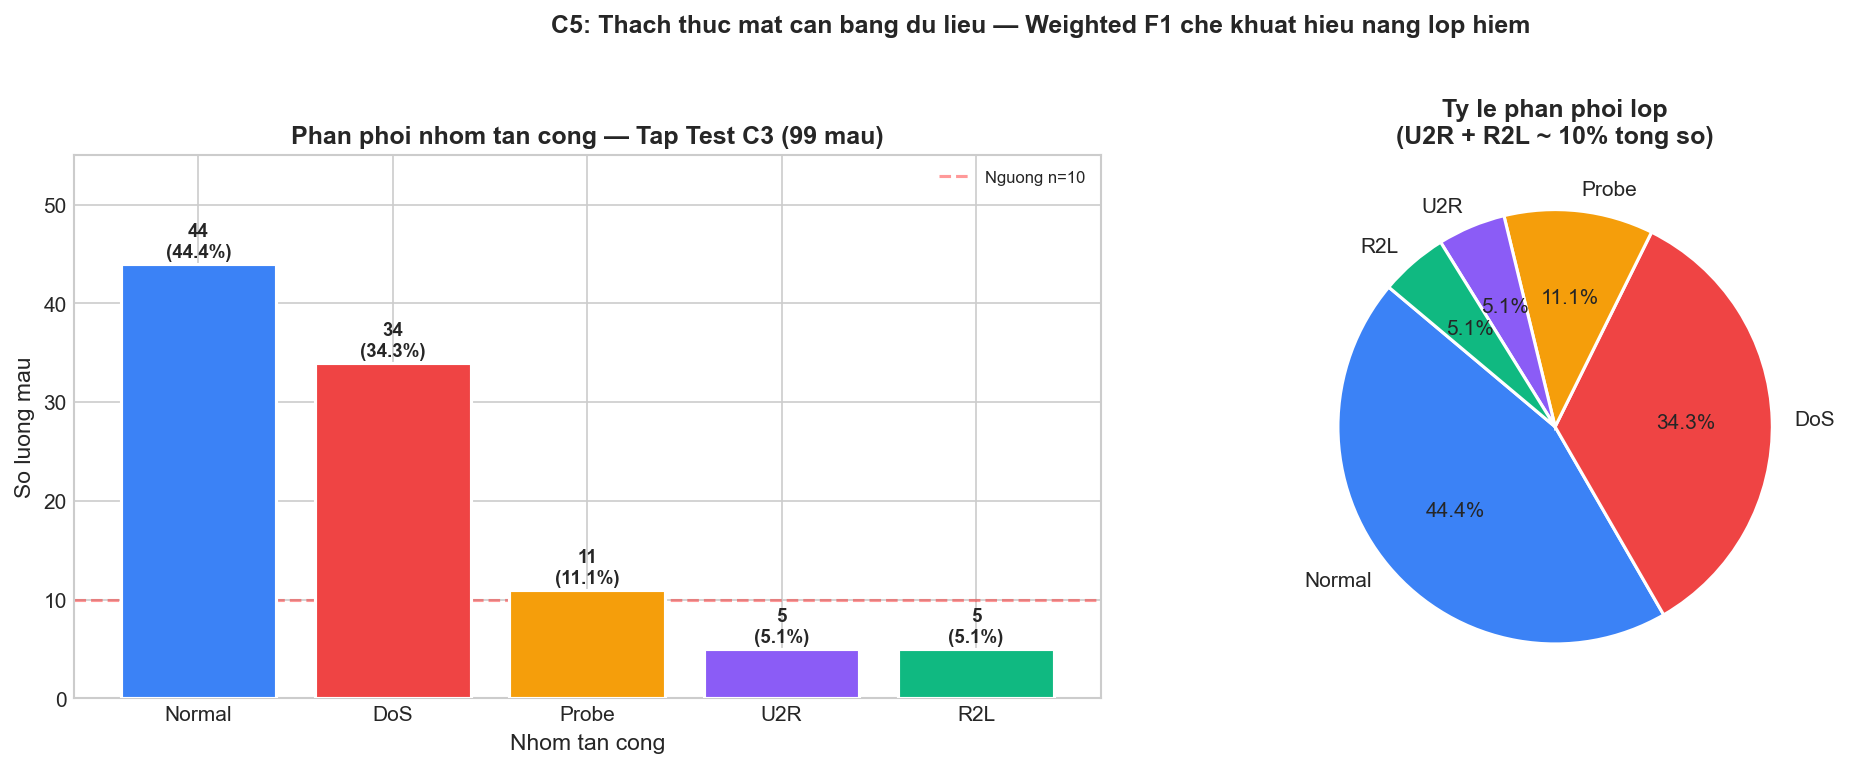

In [8]:
counts = {g: int((group_test == g).sum()) for g in GROUP_ORDER}
pcts   = {g: 100 * counts[g] / len(group_test) for g in GROUP_ORDER}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.bar(GROUP_ORDER, [counts[g] for g in GROUP_ORDER],
              color=[GROUP_COLORS[g] for g in GROUP_ORDER],
              edgecolor='white', linewidth=1.5, zorder=3)
for bar, g in zip(bars, GROUP_ORDER):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
            f'{counts[g]}\n({pcts[g]:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Phan phoi nhom tan cong — Tap Test C3 (99 mau)', fontweight='bold')
ax.set_xlabel('Nhom tan cong'); ax.set_ylabel('So luong mau')
ax.set_ylim(0, max(counts.values()) * 1.25)
ax.axhline(y=10, color='red', linestyle='--', alpha=0.4, label='Nguong n=10')
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.pie([counts[g] for g in GROUP_ORDER],
        labels=GROUP_ORDER,
        colors=[GROUP_COLORS[g] for g in GROUP_ORDER],
        autopct='%1.1f%%', startangle=140,
        wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'},
        textprops={'fontsize': 10})
ax2.set_title('Ty le phan phoi lop\n(U2R + R2L ~ 10% tong so)', fontweight='bold')

plt.suptitle('C5: Thach thuc mat can bang du lieu — Weighted F1 che khuat hieu nang lop hiem',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'c5_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Luu: reports/c5_class_distribution.png")
display(Image(filename=REPORTS_DIR / 'c5_class_distribution.png'))

## 2: Tải Mô Hình Pre-Trained & Thu Thập Dự Đoán

Tiến hành nạp 3 mô hình đã được huấn luyện tối ưu từ bộ nhớ tạm (C3 cache) và thực hiện quá trình suy luận (inference) để thu thập hai luồng dữ liệu cốt lõi:

* **Nhãn dự đoán nhị phân (Binary predictions):** $\hat{y} \in \{0, 1\}$
* **Điểm số biên quyết định (Decision function scores - Raw margins):** $$f(x) = \sum_{i \in SV} \alpha_i y_i K(x_i, x) + b$$

**Đặc tả Hệ thống Lượng tử (QSVC):** > Đối với Quantum SVM, hạt nhân lượng tử được định nghĩa bằng công thức $K_{\text{ZZ}}(x, z) = |\langle \phi(x) | \phi(z) \rangle|^2$. 
Quá trình tính toán sự chồng chập và vướng víu lượng tử này được thực thi thông qua backend **AerSimulator** với cấu hình tĩnh: `512 shots`, sử dụng mạch mã hóa đặc trưng `ZZFeatureMap` (`reps=2`, `entanglement='full'`).

In [9]:
print("Tai mo hinh tu C3 cache...")
qsvm = joblib.load(CACHE_DIR / f'qsvm_noiseless_{CONFIG_TAG}.joblib')
rbf  = joblib.load(CACHE_DIR / f'svm_rbf_mm_{CONFIG_TAG}.joblib')
poly = joblib.load(CACHE_DIR / f'svm_poly_mm_{CONFIG_TAG}.joblib')
print(f"  QSVM  type={type(qsvm).__name__} | n_sv={qsvm.n_support_}")
print(f"  RBF   type={type(rbf).__name__}  | n_sv={rbf.n_support_}  | C={rbf.C}")
print(f"  Poly  type={type(poly).__name__} | n_sv={poly.n_support_} | degree={poly.degree}")

# ── Binary predictions ────────────────────────────────────────────────────────
print("\nThu thap du doan nhi phan...")
y_pred = {}
for name, model in [('QSVM', qsvm), ('SVM-RBF', rbf), ('SVM-Poly', poly)]:
    y_pred[name] = model.predict(X_test_4d)
    f1  = f1_score(y_test, y_pred[name])
    acc = accuracy_score(y_test, y_pred[name])
    print(f"  {name:12s} | F1={f1:.4f} | Acc={acc:.4f}")

# ── Decision function scores (raw margins) ────────────────────────────────────
print("\nTinh decision function scores tren tap test...")
df_scores = {}
for name, model in [('QSVM', qsvm), ('SVM-RBF', rbf), ('SVM-Poly', poly)]:
    t0 = time.time()
    df_scores[name] = model.decision_function(X_test_4d)
    elapsed = time.time() - t0
    print(f"  {name:12s} | range=[{df_scores[name].min():.3f}, {df_scores[name].max():.3f}] | {elapsed:.1f}s")

# ── Bang hieu nang per-nhom tan cong ─────────────────────────────────────────
print("\n" + "=" * 70)
print(f"  {'Nhom':10s} | {'N':>5} | {'QSVM':>8} | {'SVM-RBF':>8} | {'SVM-Poly':>9}")
print("-" * 70)
per_group_acc = {}
for grp in GROUP_ORDER:
    mask = (group_test == grp)
    n = mask.sum()
    if n == 0:
        continue
    accs = {nm: accuracy_score(y_test[mask], y_pred[nm][mask]) for nm in MODEL_NAMES}
    per_group_acc[grp] = accs
    flag = '[R]' if grp in RARE_GROUPS else '   '
    print(f"  {flag} {grp:8s}| {n:5d} | {accs['QSVM']:>7.1%} | {accs['SVM-RBF']:>7.1%} | {accs['SVM-Poly']:>8.1%}")
print("=" * 70)
print("  [R] = Rare class | Weighted F1 bi Normal/DoS dominate.")


Tai mo hinh tu C3 cache...
  QSVM  type=QSVC | n_sv=[27 32]
  RBF   type=SVC  | n_sv=[17 17]  | C=10.0
  Poly  type=SVC | n_sv=[19 17] | degree=2

Thu thap du doan nhi phan...
  QSVM         | F1=0.8598 | Acc=0.8485
  SVM-RBF      | F1=0.8696 | Acc=0.8485
  SVM-Poly     | F1=0.8163 | Acc=0.8182

Tinh decision function scores tren tap test...
  QSVM         | range=[-1.293, 1.224] | 374.2s
  SVM-RBF      | range=[-2.269, 1.874] | 0.0s
  SVM-Poly     | range=[-1.597, 4.091] | 0.0s

  Nhom       |     N |     QSVM |  SVM-RBF |  SVM-Poly
----------------------------------------------------------------------
      Normal  |    44 |   86.4% |   77.3% |    93.2%
      DoS     |    34 |   82.4% |   91.2% |    79.4%
      Probe   |    11 |  100.0% |  100.0% |    81.8%
  [R] U2R     |     5 |   80.0% |   60.0% |    20.0%
  [R] R2L     |     5 |   60.0% |  100.0% |    60.0%
  [R] = Rare class | Weighted F1 bi Normal/DoS dominate.


## 3: Platt Scaling — Chuyển Đổi Decision Margins Sang Xác Suất

Các mô hình SVM mặc định chỉ xuất ra nhãn cứng (hard label) $\hat{y} \in \{0, 1\}$ mà không kèm theo độ tin cậy hay xác suất. 

Để đánh giá mức độ "tự tin" của mô hình, chúng ta sử dụng kỹ thuật **Platt Scaling** [Platt, 1999]. Phương pháp này sẽ khớp (fit) một hàm hồi quy logistic dạng sigmoid trên các decision scores (biên quyết định) thu được từ **tập huấn luyện (Training set)**:

$$P(y=1 \mid f) = \frac{1}{1 + e^{Af + B}}$$

Trong đó:
* $f = w \cdot x - b$ là biên quyết định (decision score) gốc.
* $(A, B)$ là các tham số của hàm sigmoid được ước lượng tối ưu bằng phương pháp Cực đại Hợp lý (Maximum Likelihood Estimation - MLE).

> **Kiểm Soát Rò Rỉ Dữ Liệu (Zero-Leakage Enforcement):**

| Bước Thực Hiện | Dữ Liệu Khai Thác | Phép Toán Tương Ứng |
|:---:|:---|:---|
| **Fit sigmoid** | `decision_function(X_train)` + `y_train` | `.fit()` ĐỘC QUYỀN trên tập Train |
| **Apply sigmoid** | `decision_function(X_test)` + Platt Model | `.predict_proba()` áp dụng lên tập Test |

In [10]:
class PlattScaler:
    # Platt Scaling: anh xa decision scores sang P(y=1|f) qua sigmoid logistic.
    # Duoc fit HOAN TOAN tren training set de dam bao zero-leakage.

    def __init__(self, C=1e10):
        # C rat lon -> logistic regression khong regularize -> fit sigmoid chinh xac
        self.lr = LogisticRegression(C=C, solver='lbfgs', max_iter=2000, random_state=42)

    def fit(self, train_scores, y):
        # Fit sigmoid tren training decision scores (zero-leakage compliant).
        self.lr.fit(train_scores.reshape(-1, 1), y)
        A = self.lr.coef_[0][0]
        B = self.lr.intercept_[0]
        return self, A, B

    def predict_proba(self, scores):
        # Tra ve P(y=1|score) — ap dung sigmoid da fit.
        return self.lr.predict_proba(scores.reshape(-1, 1))[:, 1]


# ── Buoc 1: Decision scores tren TRAINING SET ─────────────────────────────────
print("Tinh decision scores tren training set de fit Platt Scaling...")
df_train_scores = {}
for name, model in [('QSVM', qsvm), ('SVM-RBF', rbf), ('SVM-Poly', poly)]:
    t0 = time.time()
    df_train_scores[name] = model.decision_function(X_train_4d)
    print(f"  [{name}] xong ({time.time()-t0:.1f}s) | "
          f"range=[{df_train_scores[name].min():.3f}, {df_train_scores[name].max():.3f}]")

# ── Buoc 2: Fit Platt Scaler (tren training data) ─────────────────────────────
print("\nFit Platt Scalers:")
platt_scalers, platt_params = {}, {}
for name in MODEL_NAMES:
    scaler, A, B = PlattScaler().fit(df_train_scores[name], y_train)
    platt_scalers[name] = scaler
    platt_params[name]  = {'A': round(float(A), 5), 'B': round(float(B), 5)}
    print(f"  [{name:12s}] A={A:+.4f}, B={B:+.4f}")

# ── Buoc 3: Ap dung tren TEST SET ─────────────────────────────────────────────
prob = {name: platt_scalers[name].predict_proba(df_scores[name]) for name in MODEL_NAMES}

print("\nKiem tra xac suat da hieu chinh (5 mau dau):")
check = pd.DataFrame({
    'y_true':      y_test[:5],
    'QSVM_pred':   y_pred['QSVM'][:5],
    'QSVM_prob':   prob['QSVM'][:5].round(3),
    'RBF_pred':    y_pred['SVM-RBF'][:5],
    'RBF_prob':    prob['SVM-RBF'][:5].round(3),
    'Poly_pred':   y_pred['SVM-Poly'][:5],
    'Poly_prob':   prob['SVM-Poly'][:5].round(3),
})
print(check.to_string(index=False))
print("\nPlatt Scaling hoan tat.")


Tinh decision scores tren training set de fit Platt Scaling...
  [QSVM] xong (426.1s) | range=[-1.267, 1.269]
  [SVM-RBF] xong (0.0s) | range=[-2.277, 1.896]
  [SVM-Poly] xong (0.0s) | range=[-1.420, 3.595]

Fit Platt Scalers:
  [QSVM        ] A=+6.6442, B=-0.7539
  [SVM-RBF     ] A=+2.7952, B=-0.6789
  [SVM-Poly    ] A=+2.1019, B=-0.1361

Kiem tra xac suat da hieu chinh (5 mau dau):
 y_true  QSVM_pred  QSVM_prob  RBF_pred  RBF_prob  Poly_pred  Poly_prob
      0          0      0.001         0     0.001          0      0.057
      1          1      0.997         1     0.896          1      0.991
      1          1      0.997         1     0.902          1      0.998
      1          0      0.005         0     0.010          0      0.030
      1          1      0.955         1     0.832          0      0.407

Platt Scaling hoan tat.


### 3.1 Phân Phối Xác Suất Sau Hiệu Chuẩn

Biểu đồ **Violin Plot** dưới đây trực quan hóa mật độ phân bố xác suất dự đoán $P(y=1|x)$ của từng mô hình, được phân tách rõ ràng theo **nhãn thực tế** (0 = Normal, 1 = Attack).

**Tiêu chí đánh giá mô hình được hiệu chuẩn tốt (Well-calibrated):**
* Phân bố xác suất đối với lớp thực tế 0 (Normal) phải tập trung dày đặc ở vùng đáy (sát mức `0.0`).
* Phân bố xác suất đối với lớp thực tế 1 (Attack) phải tập trung dày đặc ở vùng đỉnh (sát mức `1.0`).
* Những điểm dữ liệu rơi rớt ở khu vực lơ lửng quanh ngưỡng `0.5` thể hiện sự "lưỡng lự" (uncertainty) hoặc mức độ khó phân loại của biên quyết định.

Luu: reports/c5_probability_distributions.png


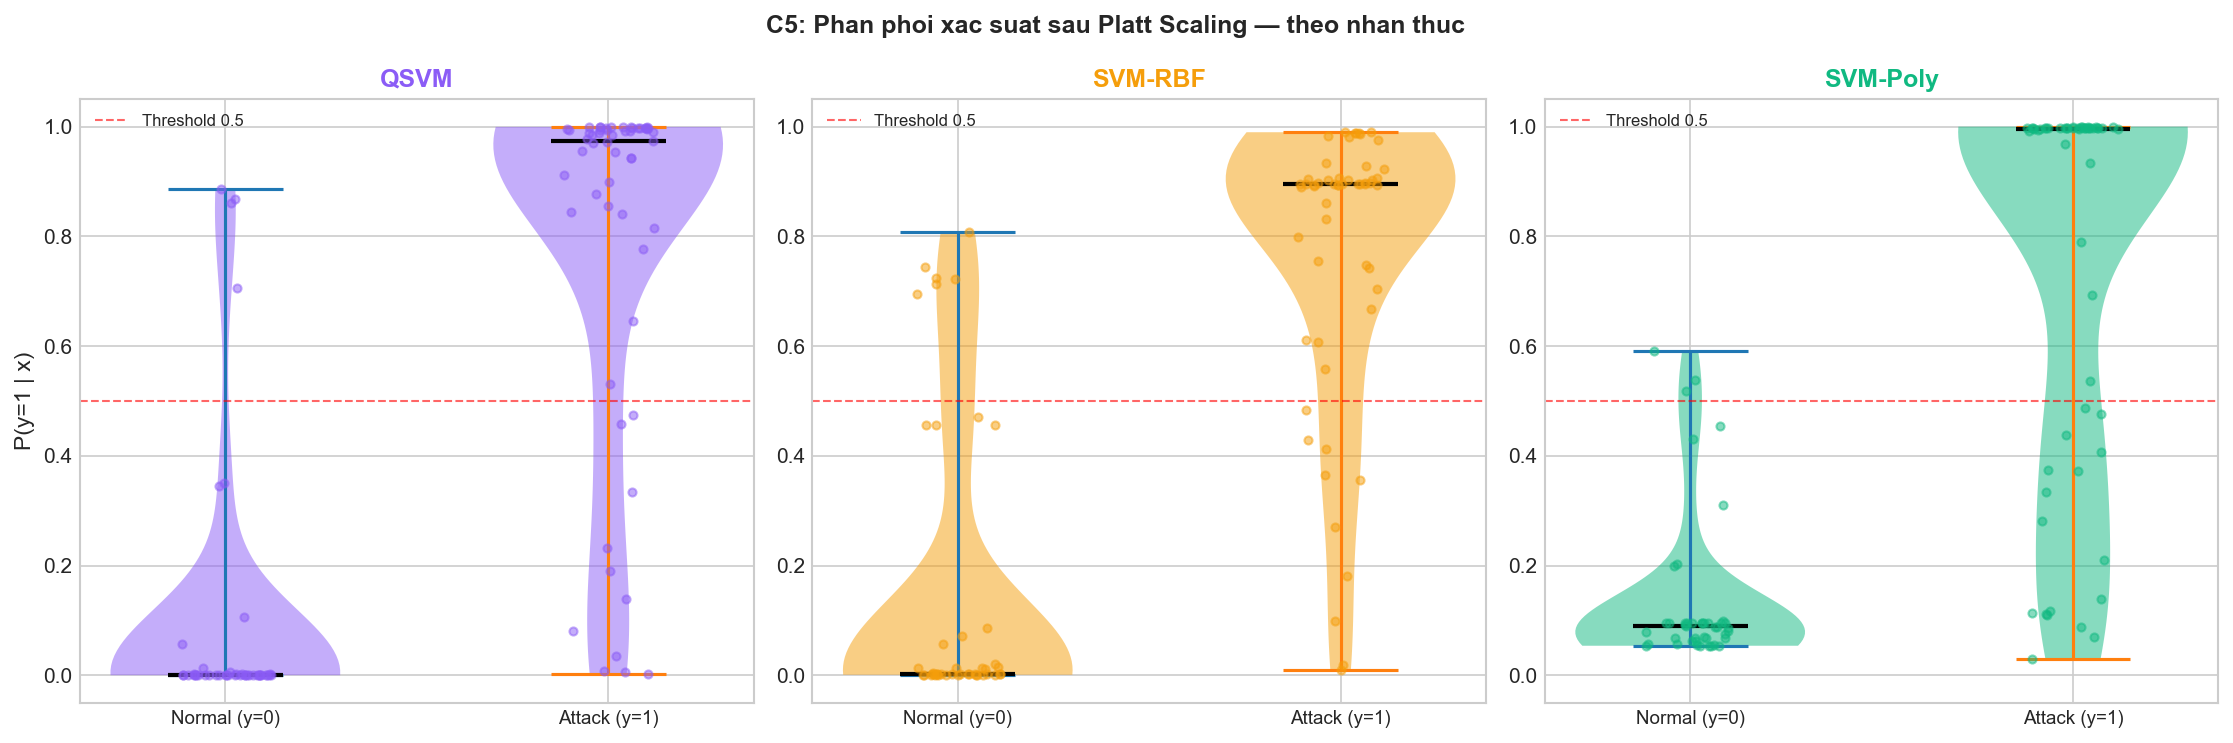

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, name in zip(axes, MODEL_NAMES):
    p     = prob[name]
    color = MODEL_COLORS[name]
    for cls, x_pos in [(0, 0), (1, 1)]:
        mask_cls = (y_test == cls)
        vals = p[mask_cls]
        parts = ax.violinplot(vals, positions=[x_pos], widths=0.6,
                              showmedians=True, showextrema=True)
        for pc in parts['bodies']:
            pc.set_facecolor(color); pc.set_alpha(0.5)
        parts['cmedians'].set_colors('black'); parts['cmedians'].set_linewidth(2)
        jitter = np.random.uniform(-0.12, 0.12, size=vals.shape)
        ax.scatter(x_pos + jitter, vals, color=color, alpha=0.5, s=15, zorder=3)

    ax.axhline(0.5, color='red', linestyle='--', alpha=0.6, lw=1, label='Threshold 0.5')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Normal (y=0)', 'Attack (y=1)'], fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('P(y=1 | x)' if name == 'QSVM' else '')
    ax.set_title(name, color=color, fontweight='bold', fontsize=12)
    ax.legend(fontsize=8)

plt.suptitle('C5: Phan phoi xac suat sau Platt Scaling — theo nhan thuc',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'c5_probability_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Luu: reports/c5_probability_distributions.png")
display(Image(filename=REPORTS_DIR / 'c5_probability_distributions.png'))

## 4: Reliability Diagram & ECE/MCE — Adaptive Binning

### Vấn Đề Về "Thùng Rỗng" (Empty Bins)
Với phương pháp Equal-Width Binning truyền thống (chia các khoảng xác suất đều nhau, ví dụ: $[0, 0.1), [0.1, 0.2)...$), các lớp tấn công hiếm như **U2R/R2L** (chỉ có 5 mẫu mỗi loại) sẽ chắc chắn tạo ra các **Empty Bins** (bin không chứa mẫu nào). Điều này làm sai lệch nghiêm trọng kết quả tính toán ECE.

**Giải Pháp: Equal-Frequency (Adaptive) Binning**
Chúng ta áp dụng kỹ thuật chia bin thích ứng, trong đó ranh giới các bin được dịch chuyển linh hoạt sao cho mỗi bin chứa **số lượng mẫu (N) bằng nhau**. 

Các chỉ số đánh giá độ hiệu chuẩn được định nghĩa như sau:

**Expected Calibration Error (ECE):**
$$\text{ECE} = \sum_{m=1}^{M} \frac{|B_m|}{n} \left| \text{acc}(B_m) - \overline{\text{conf}}(B_m) \right|$$

**Maximum Calibration Error (MCE):**
$$\text{MCE} = \max_{m} \left| \text{acc}(B_m) - \overline{\text{conf}}(B_m) \right|$$

> **Hướng dẫn đọc đồ thị (Reliability Curve):**
> * **Perfect calibration:** Đường cong bám sát và nằm chồng lên đường chéo lý tưởng ($\text{acc} = \text{conf}$).
> * **Over-confident (Tự tin thái quá):** Đường cong nằm hoàn toàn phía dưới đường chéo. Mô hình đưa ra xác suất rất cao nhưng tỷ lệ đoán trúng thực tế lại thấp.
> * **Under-confident (Thiếu tự tin):** Đường cong nằm phía trên đường chéo.

In [12]:
def adaptive_calibration_curve(y_true, y_prob, n_bins=10):
    # Tinh calibration curve voi Equal-Frequency Binning.
    # Tranh empty bins cho cac lop hiem U2R/R2L.
    n             = len(y_prob)
    sorted_idx    = np.argsort(y_prob)
    y_prob_sorted = y_prob[sorted_idx]
    y_true_sorted = y_true[sorted_idx]

    bin_size = max(n // n_bins, 1)
    mean_conf, frac_pos, bin_sizes = [], [], []

    for i in range(n_bins):
        start = i * bin_size
        end   = (i + 1) * bin_size if i < n_bins - 1 else n
        if start >= n:
            break
        b_true = y_true_sorted[start:end]
        b_prob = y_prob_sorted[start:end]
        if len(b_true) == 0:
            continue
        mean_conf.append(float(np.mean(b_prob)))
        frac_pos.append(float(np.mean(b_true)))
        bin_sizes.append(len(b_true))

    return np.array(mean_conf), np.array(frac_pos), np.array(bin_sizes)


def compute_ece_mce(y_true, y_prob, n_bins=10):
    # Tinh ECE va MCE voi adaptive binning.
    mc, fp, bs = adaptive_calibration_curve(y_true, y_prob, n_bins)
    n   = len(y_true)
    ece = float(np.sum(bs / n * np.abs(fp - mc)))
    mce = float(np.max(np.abs(fp - mc))) if len(mc) > 0 else float('nan')
    return ece, mce


# ── Tinh ECE/MCE toan bo tap test ────────────────────────────────────────────
print("ECE / MCE — Toan bo tap test (99 mau, n_bins=10):")
ece_results = {}
for name in MODEL_NAMES:
    ece, mce = compute_ece_mce(y_test, prob[name], n_bins=10)
    ece_results[name] = {'ece_full': ece, 'mce_full': mce}
    print(f"  {name:12s} | ECE={ece:.4f} | MCE={mce:.4f}")

# ── Tinh ECE/MCE cho lop hiem (U2R + R2L) ────────────────────────────────────
rare_mask = np.isin(group_test, RARE_GROUPS)
print(f"\nECE / MCE — Rare class only (U2R+R2L, n={rare_mask.sum()}, n_bins=5):")
for name in MODEL_NAMES:
    if rare_mask.sum() > 1:
        ece_r, mce_r = compute_ece_mce(y_test[rare_mask], prob[name][rare_mask], n_bins=5)
    else:
        ece_r, mce_r = float('nan'), float('nan')
    ece_results[name]['ece_rare'] = ece_r
    ece_results[name]['mce_rare'] = mce_r
    print(f"  {name:12s} | ECE={ece_r:.4f} | MCE={mce_r:.4f}")


ECE / MCE — Toan bo tap test (99 mau, n_bins=10):
  QSVM         | ECE=0.1065 | MCE=0.4849
  SVM-RBF      | ECE=0.1219 | MCE=0.4422
  SVM-Poly     | ECE=0.0980 | MCE=0.4357

ECE / MCE — Rare class only (U2R+R2L, n=10, n_bins=5):
  QSVM         | ECE=0.4337 | MCE=0.9785
  SVM-RBF      | ECE=0.4707 | MCE=0.9410
  SVM-Poly     | ECE=0.6191 | MCE=0.8996


### 4.1 Reliability Diagrams — Toàn Bộ Tập Test & Lớp Hiếm (Rare Class)

Phần trực quan hóa độ tin cậy được chia làm hai góc độ: Đánh giá tổng quan trên toàn bộ 99 mẫu và đánh giá "soi rọi" cục bộ trên nhóm tấn công hiếm (U2R + R2L).

**Hướng dẫn đọc biểu đồ:**
* **Đường chéo nét đứt (Perfect Calibration):** Thể hiện sự hiệu chuẩn hoàn hảo (Độ tự tin trung bình = Độ chính xác thực tế).
* **Thanh sai lệch (Gap bars):** Biểu diễn khoảng cách sai số hiệu chuẩn. Độ dài thanh chính là giá trị tuyệt đối $|\text{acc} - \text{conf}|$.
  * *Thanh màu Đỏ:* Mô hình đang "tự tin thái quá" (Over-confident).
  * *Thanh màu Xanh:* Mô hình đang "thiếu tự tin" (Under-confident).
* **Kích thước điểm (Scatter Size):** Tỉ lệ thuận với số lượng mẫu ($n$) rơi vào Bin đó, giúp minh chứng bằng mắt thường rằng thuật toán Adaptive Binning đã bẻ cong các Bin để gom đủ số lượng mẫu.

Luu: reports/c5_reliability_diagrams_full.png


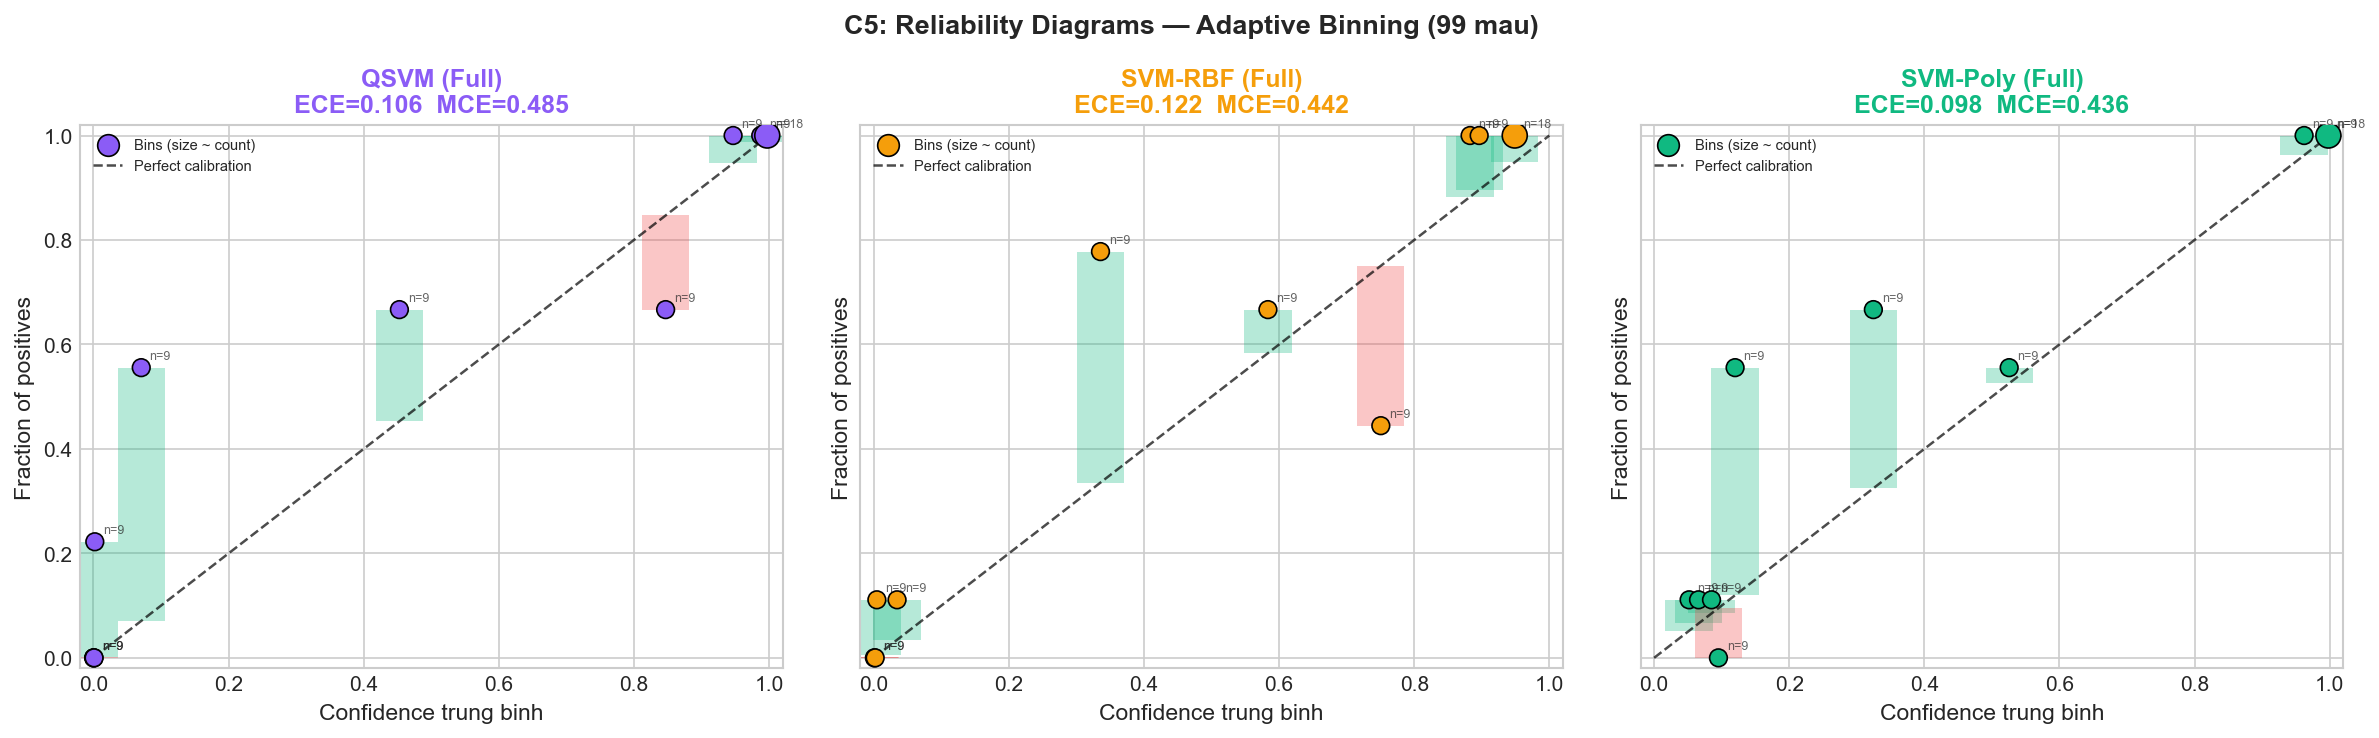

Luu: reports/c5_reliability_diagrams_rare.png


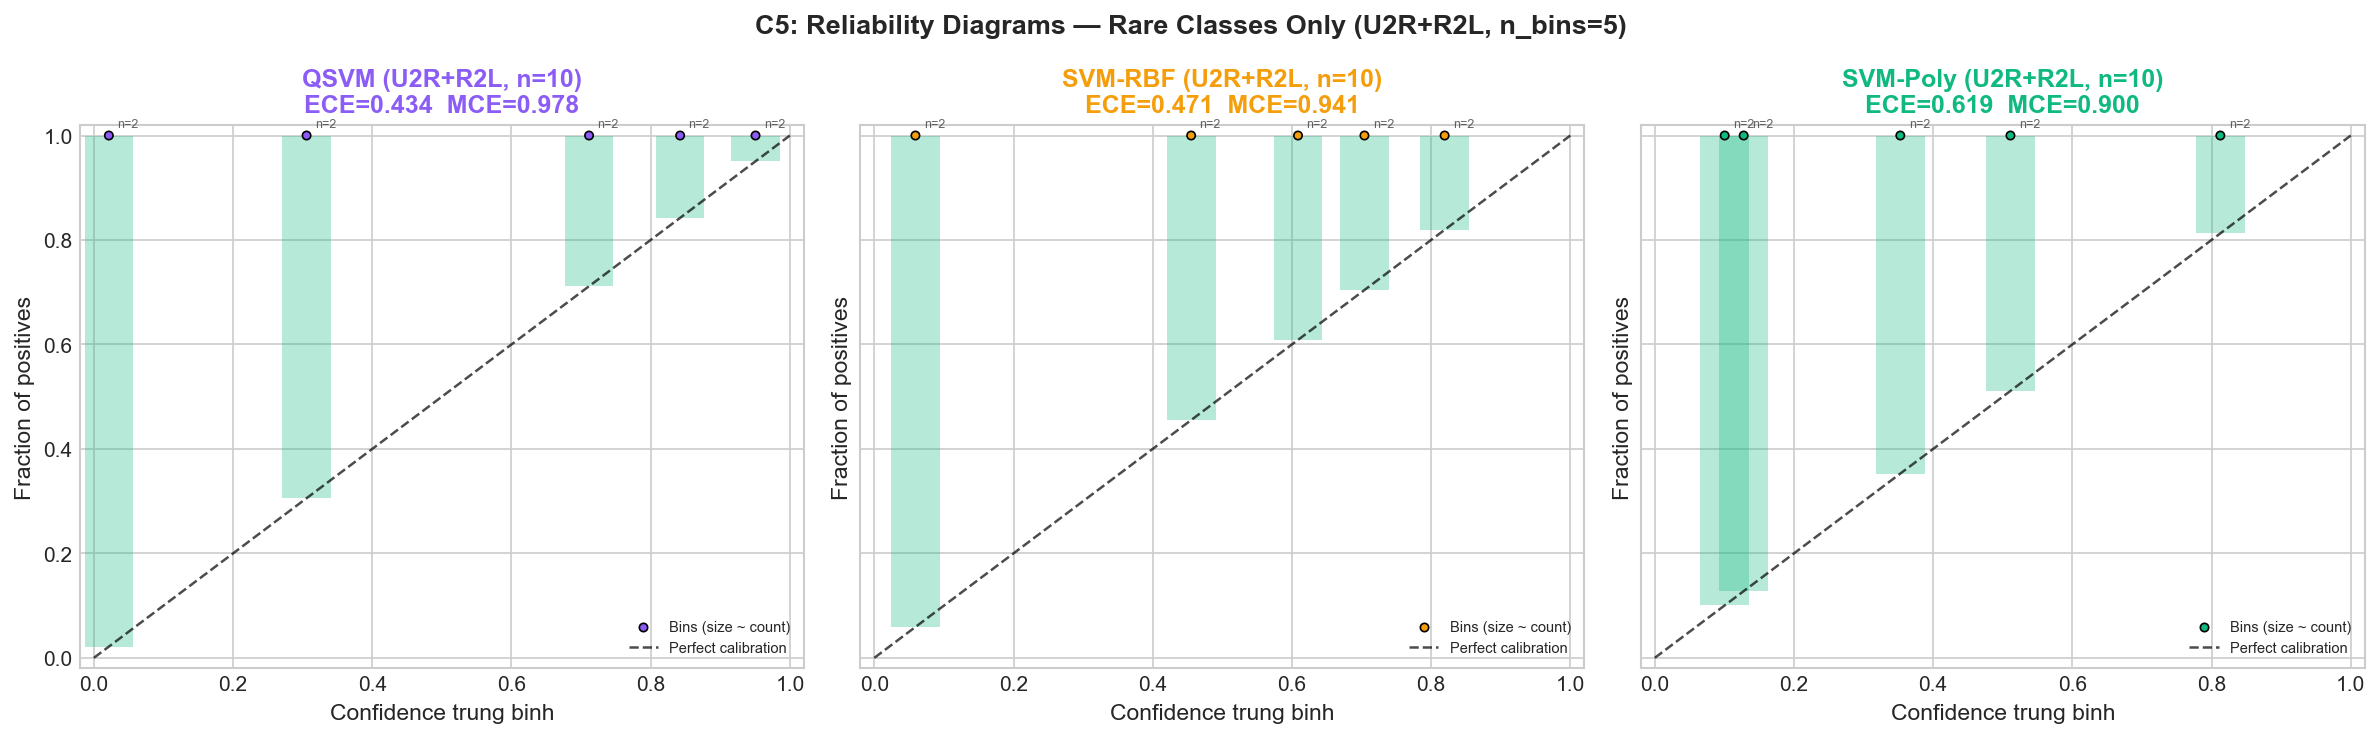

In [15]:
def plot_reliability_diagram(ax, y_true, y_prob, n_bins, name, color, ece, mce, suffix=''):
    # Ve reliability diagram voi adaptive binning len axes ax.
    mc, fp, bs = adaptive_calibration_curve(y_true, y_prob, n_bins)
    for xi, yi in zip(mc, fp):
        lo, hi = min(xi, yi), max(xi, yi)
        c = '#EF4444' if yi < xi else '#10B981'
        ax.bar(xi, hi - lo, bottom=lo, width=0.07, color=c, alpha=0.3, zorder=2)
    ax.scatter(mc, fp, s=[b * 8 for b in bs], color=color,
               edgecolors='black', lw=0.8, zorder=5, label='Bins (size ~ count)')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.7, label='Perfect calibration')
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel('Confidence trung binh')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'{name}{suffix}\nECE={ece:.3f}  MCE={mce:.3f}',
                 color=color, fontweight='bold')
    ax.legend(fontsize=7)
    for xi, yi, b in zip(mc, fp, bs):
        ax.annotate(f'n={b}', (xi, yi), textcoords='offset points',
                    xytext=(4, 4), fontsize=6, alpha=0.7)


# ── Full test set ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, name in zip(axes, MODEL_NAMES):
    plot_reliability_diagram(ax, y_test, prob[name], 10,
                             name, MODEL_COLORS[name],
                             ece_results[name]['ece_full'],
                             ece_results[name]['mce_full'], ' (Full)')
plt.suptitle('C5: Reliability Diagrams — Adaptive Binning (99 mau)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'c5_reliability_diagrams_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("Luu: reports/c5_reliability_diagrams_full.png")
display(Image(filename=REPORTS_DIR / 'c5_reliability_diagrams_full.png'))
# ── Rare class only ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, name in zip(axes, MODEL_NAMES):
    plot_reliability_diagram(ax, y_test[rare_mask], prob[name][rare_mask], 5,
                             name, MODEL_COLORS[name],
                             ece_results[name]['ece_rare'],
                             ece_results[name]['mce_rare'],
                             f' (U2R+R2L, n={rare_mask.sum()})')
plt.suptitle('C5: Reliability Diagrams — Rare Classes Only (U2R+R2L, n_bins=5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'c5_reliability_diagrams_rare.png', dpi=150, bbox_inches='tight')
plt.show()
print("Luu: reports/c5_reliability_diagrams_rare.png")
display(Image(filename=REPORTS_DIR / 'c5_reliability_diagrams_rare.png'))

## 5: Decision Margin Histogram — Phân Tích Biên Quyết Định

**Biên quyết định (Decision margin)**, ký hiệu là $|f(x)| = |w \cdot \phi(x) - b|$, đo lường khoảng cách hình học từ mẫu dữ liệu $x$ đến siêu phẳng phân lớp (hyperplane) trong không gian đặc trưng. 
* **Margin lớn:** Mẫu nằm sâu trong vùng an toàn ➔ Mô hình có độ tự tin cao.
* **Margin nhỏ:** Mẫu nằm sát ranh giới phân lớp ➔ Sự phân vân (Uncertainty) lớn, rủi ro phân loại sai cao.

**Câu hỏi khoa học (Giả thuyết H2):** Liệu không gian Hilbert lượng tử của QSVM có giúp phân bố margin của các mẫu thuộc lớp hiếm (U2R/R2L) trở nên tập trung và rõ ràng hơn so với không gian của SVM truyền thống hay không?

Chúng ta sẽ phân tích đa chiều thông qua 2 góc độ:
1. **Phân rã theo độ chính xác (Correct vs. Incorrect):** Đối chiếu mật độ margin của các mẫu được mô hình dự đoán đúng so với các mẫu dự đoán sai.
2. **Phân rã theo nhóm tấn công (Per-Attack Group):** Trực quan hóa giá trị trung vị (Median margin) kèm khoảng tứ phân vị (IQR) cho từng nhóm tấn công cụ thể.

Luu: reports/c5_margin_histograms.png


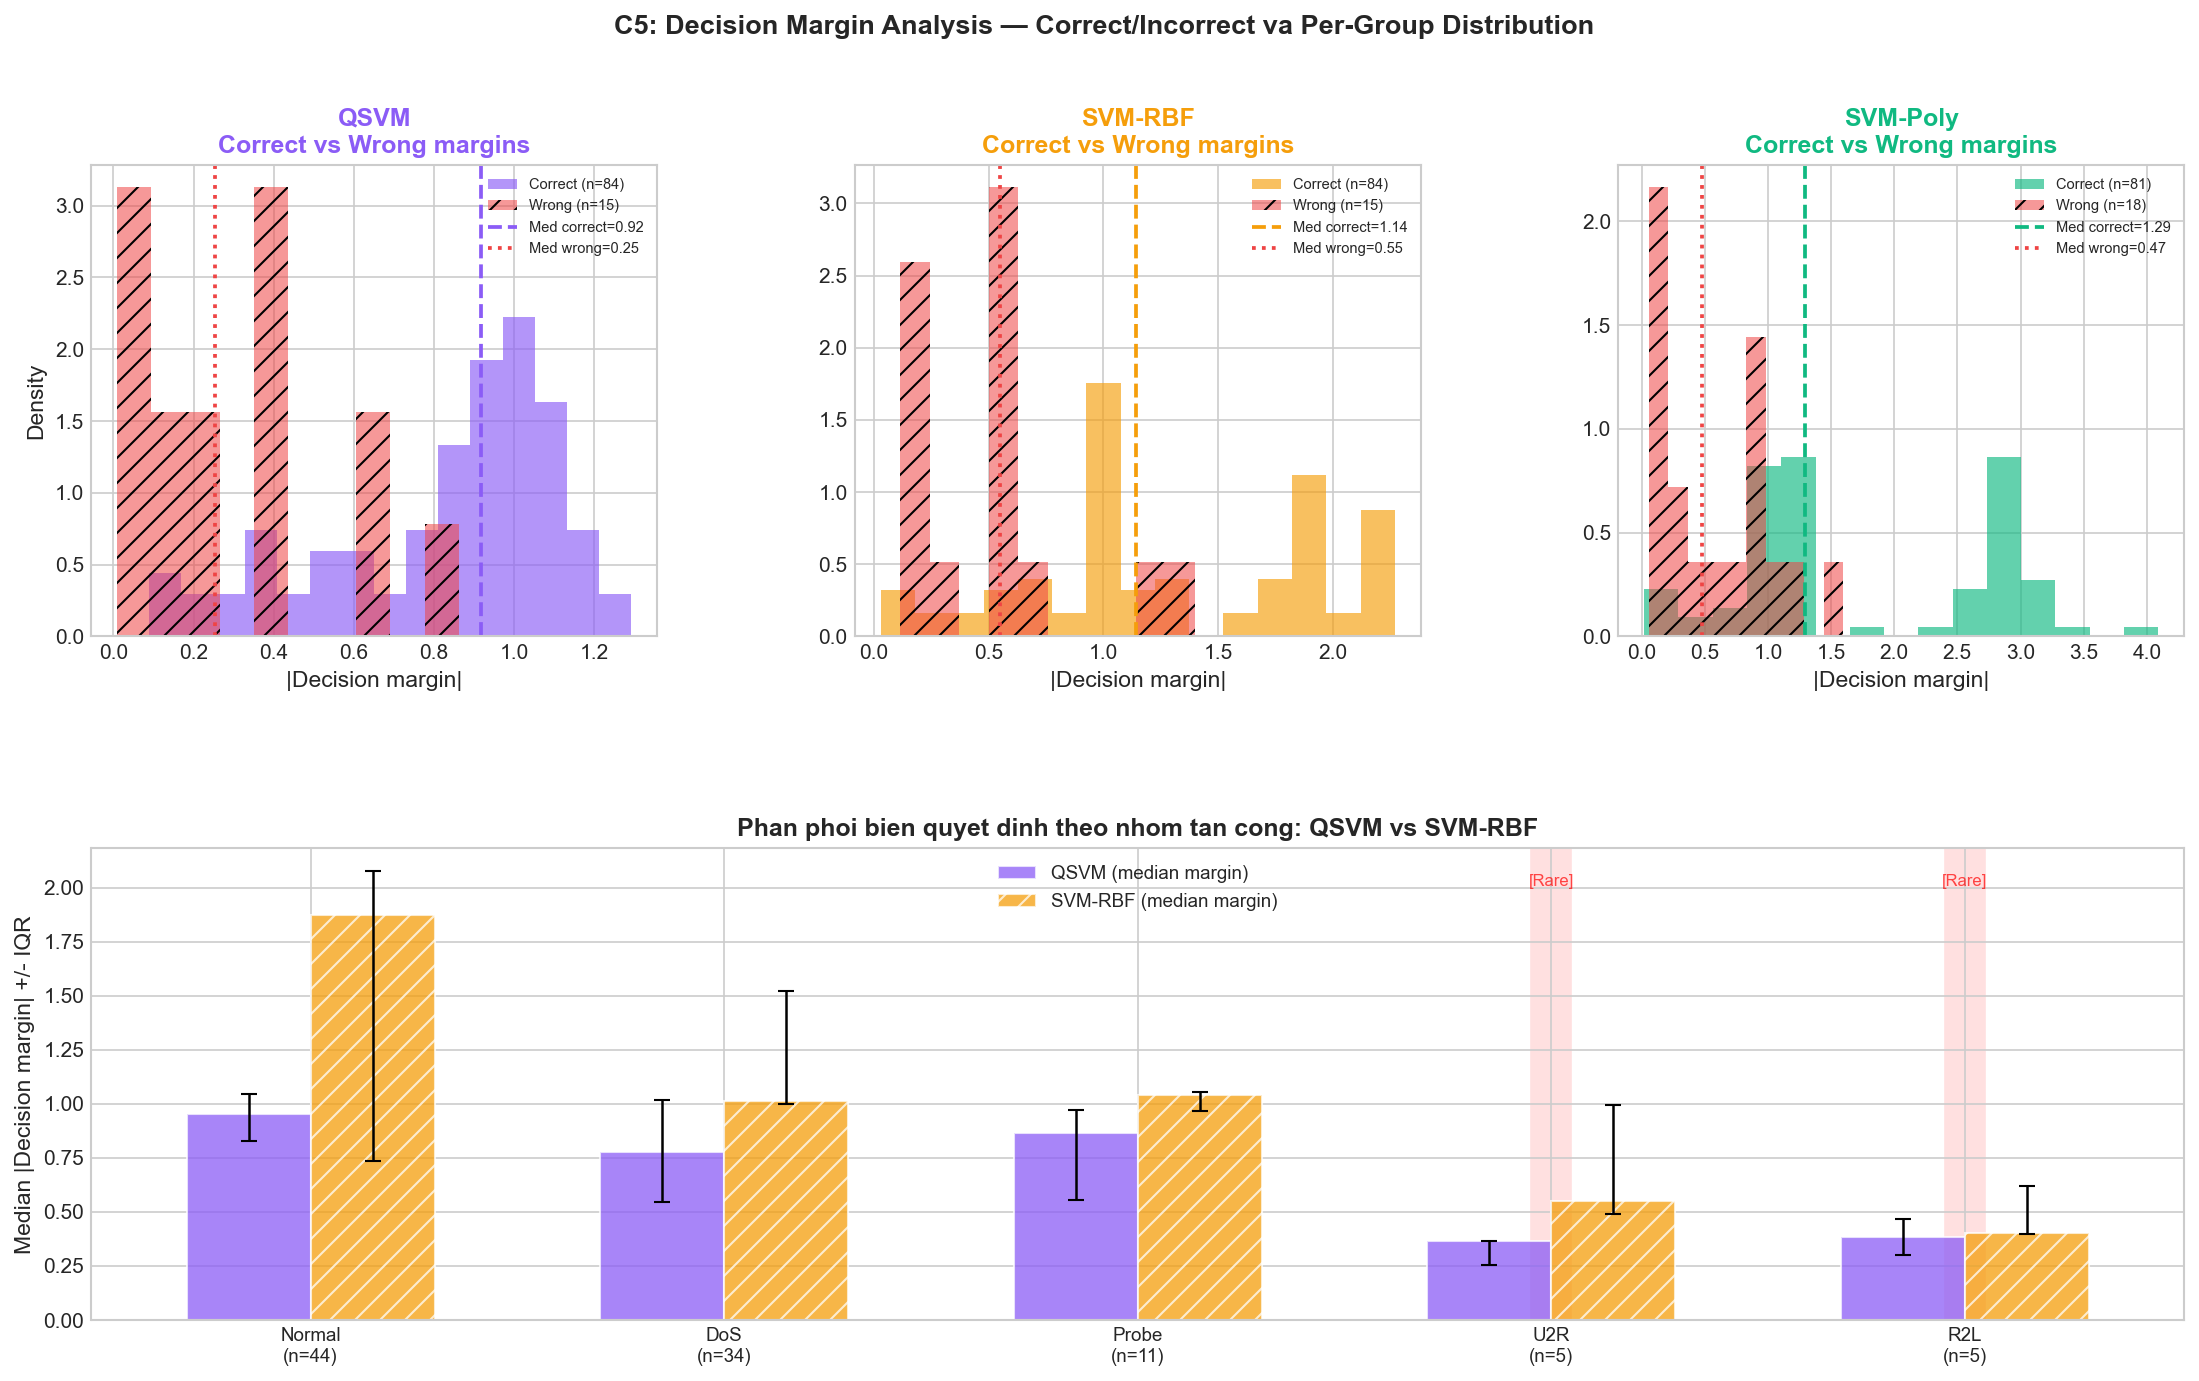

In [16]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Hang tren: Correct vs Incorrect margin ───────────────────────────────────
for col, name in enumerate(MODEL_NAMES):
    ax    = fig.add_subplot(gs[0, col])
    raw   = df_scores[name]
    color = MODEL_COLORS[name]

    correct_mask   = (y_pred[name] == y_test)
    incorrect_mask = ~correct_mask

    ax.hist(np.abs(raw[correct_mask]), bins=15, alpha=0.65,
            color=color, label=f'Correct (n={correct_mask.sum()})', density=True)
    if incorrect_mask.sum() > 0:
        ax.hist(np.abs(raw[incorrect_mask]), bins=10, alpha=0.55, color='#EF4444',
                label=f'Wrong (n={incorrect_mask.sum()})', density=True, hatch='//')

    med_c = np.median(np.abs(raw[correct_mask]))
    ax.axvline(med_c, color=color, lw=1.8, linestyle='--', label=f'Med correct={med_c:.2f}')
    if incorrect_mask.sum() > 0:
        med_w = np.median(np.abs(raw[incorrect_mask]))
        ax.axvline(med_w, color='#EF4444', lw=1.8, linestyle=':', label=f'Med wrong={med_w:.2f}')

    ax.set_title(f'{name}\nCorrect vs Wrong margins', color=color, fontweight='bold')
    ax.set_xlabel('|Decision margin|')
    ax.set_ylabel('Density' if col == 0 else '')
    ax.legend(fontsize=7)

# ── Hang duoi: Per-group median margin (QSVM vs SVM-RBF) ────────────────────
ax_bot = fig.add_subplot(gs[1, :])
width  = 0.3
x_pos  = np.arange(len(GROUP_ORDER))

for i, (name, offset, hatch) in enumerate([('QSVM', -width/2, ''), ('SVM-RBF', width/2, '//')]):
    medians, q25s, q75s = [], [], []
    for grp in GROUP_ORDER:
        mask = (group_test == grp)
        vals = np.abs(df_scores[name][mask]) if mask.sum() > 0 else np.array([0.0])
        medians.append(np.median(vals))
        q25s.append(np.percentile(vals, 25))
        q75s.append(np.percentile(vals, 75))
    medians, q25s, q75s = np.array(medians), np.array(q25s), np.array(q75s)

    ax_bot.bar(x_pos + offset, medians, width=width, color=MODEL_COLORS[name],
               alpha=0.75, label=f'{name} (median margin)', hatch=hatch, edgecolor='white')
    ax_bot.errorbar(x_pos + offset, medians,
                    yerr=[medians - q25s, q75s - medians],
                    fmt='none', color='black', capsize=4, lw=1.2)

ax_bot.set_xticks(x_pos)
ax_bot.set_xticklabels([f'{g}\n(n={sum(group_test==g)})' for g in GROUP_ORDER], fontsize=9)
ax_bot.set_ylabel('Median |Decision margin| +/- IQR')
ax_bot.set_title('Phan phoi bien quyet dinh theo nhom tan cong: QSVM vs SVM-RBF',
                 fontweight='bold')
ax_bot.legend(fontsize=9)

for i, g in enumerate(GROUP_ORDER):
    if g in RARE_GROUPS:
        ax_bot.axvline(i, color='red', alpha=0.12, lw=20, zorder=0)
        ax_bot.text(i, ax_bot.get_ylim()[1] * 0.92, '[Rare]',
                    ha='center', fontsize=8, color='red', alpha=0.7)

plt.suptitle('C5: Decision Margin Analysis — Correct/Incorrect va Per-Group Distribution',
             fontsize=13, fontweight='bold')
plt.savefig(REPORTS_DIR / 'c5_margin_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("Luu: reports/c5_margin_histograms.png")
display(Image(filename=REPORTS_DIR / 'c5_margin_histograms.png'))

## 6: Phân Tích ROC Curve — Tiêu Điểm Vùng FPR 1% - 5%

Trong môi trường triển khai Hệ thống Phát hiện Xâm nhập (IDS) thực tế, chỉ số quan trọng nhất không phải là độ chính xác tổng thể, mà là khả năng nhận diện tấn công (TPR) **khi giữ tỷ lệ Báo động nhầm (False Positive Rate - FPR) ở mức cực thấp**. 

Nếu FPR vượt ngưỡng 5%, số lượng cảnh báo rác (False Alarms) sinh ra sẽ quá lớn, dẫn đến hiện tượng *căng thẳng cảnh báo (alert fatigue)* khiến các kỹ sư bảo mật (SOC Operators) có xu hướng bỏ qua cả những cảnh báo thật.

Các chỉ số toán học:
* **FPR (False Positive Rate):** $\text{FPR} = \frac{FP}{FP + TN}$
* **AUC-ROC:** Diện tích dưới đường cong, đo lường khả năng phân tách trung bình của mô hình: $\text{AUC-ROC} = \int_0^1 \text{TPR}(t) \, d\text{FPR}(t)$

> **Phân Tích Chuyên Sâu (Inset Zoom):**
> Hình chữ nhật nhỏ bên trong biểu đồ sẽ **phóng to (zoom)** vào vùng hoạt động lý tưởng với $\text{FPR} \in [0, 0.08]$ để quan sát sát sao hiệu năng thực tế.
> * **Hình thoi (◆):** Điểm vận hành tại $\text{FPR} \approx 1\%$.
> * **Hình vuông (■):** Điểm vận hành tại $\text{FPR} \approx 5\%$.

Luu: reports/c5_roc_curves.png


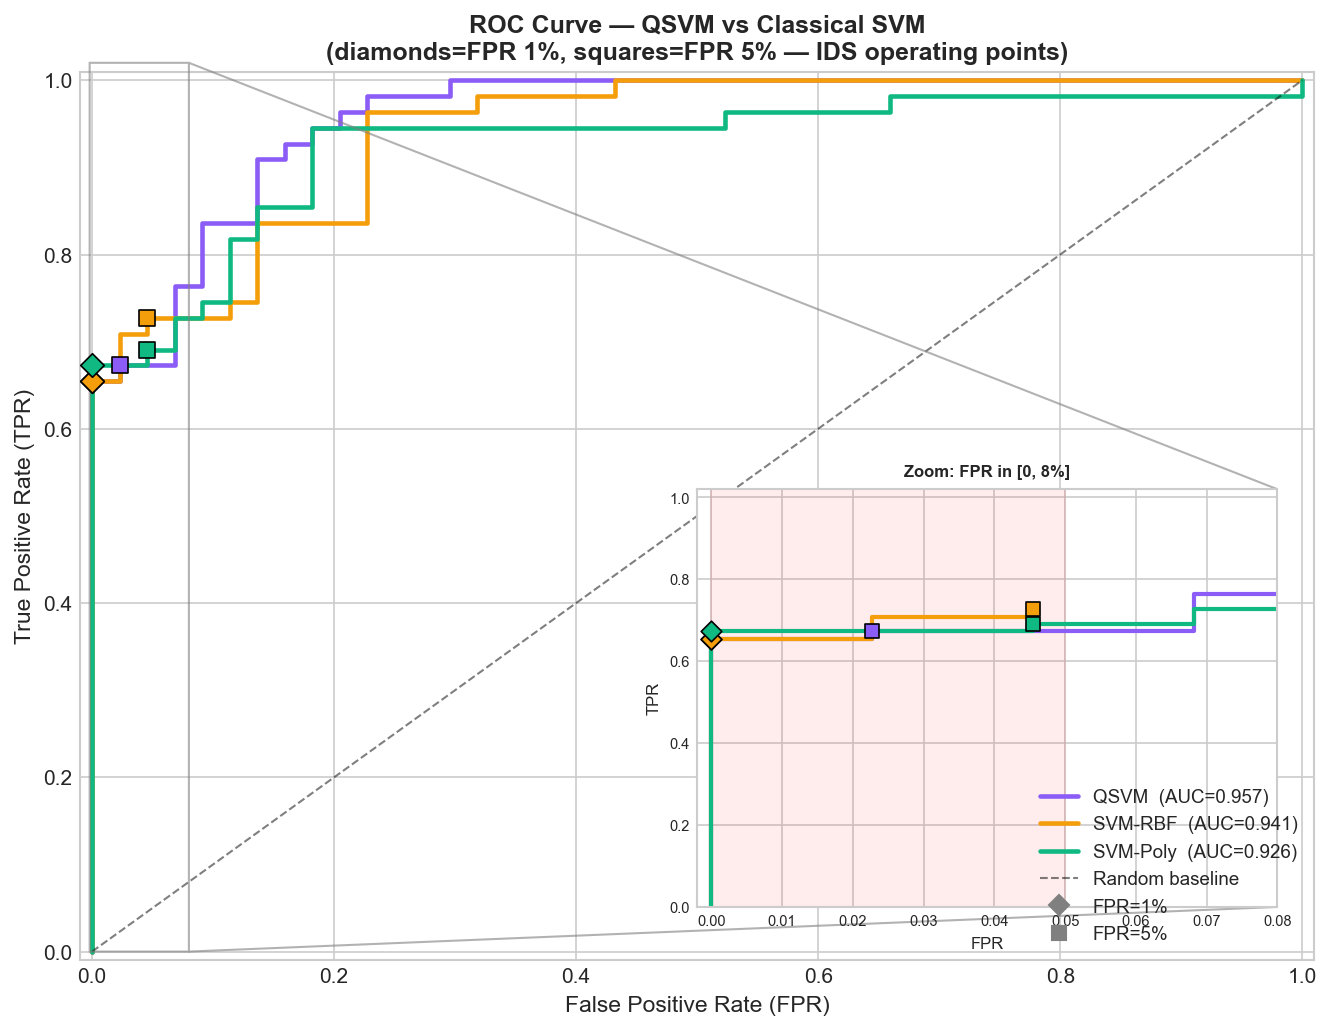


AUC-ROC:
  QSVM         | 0.9574
  SVM-RBF      | 0.9409
  SVM-Poly     | 0.9256


In [17]:
roc_data, roc_auc_vals = {}, {}

fig, ax_main = plt.subplots(1, 1, figsize=(9, 7))
for name in MODEL_NAMES:
    fpr, tpr, _      = roc_curve(y_test, prob[name])
    roc_auc_vals[name] = auc(fpr, tpr)
    roc_data[name]   = {'fpr': fpr.tolist(), 'tpr': tpr.tolist(), 'auc': roc_auc_vals[name]}
    ax_main.plot(fpr, tpr, color=MODEL_COLORS[name], lw=2.2,
                 label=f'{name}  (AUC={roc_auc_vals[name]:.3f})')
    for target_fpr, marker, ms in [(0.01, 'D', 8), (0.05, 's', 8)]:
        idx = np.clip(np.searchsorted(fpr, target_fpr, side='right') - 1, 0, len(fpr)-1)
        ax_main.scatter(fpr[idx], tpr[idx], color=MODEL_COLORS[name],
                        marker=marker, s=ms**2, zorder=6, edgecolors='black', lw=0.8)

ax_main.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random baseline')
ax_main.set_xlabel('False Positive Rate (FPR)')
ax_main.set_ylabel('True Positive Rate (TPR)')
ax_main.set_title('ROC Curve — QSVM vs Classical SVM\n'
                  '(diamonds=FPR 1%, squares=FPR 5% — IDS operating points)', fontweight='bold')
ax_main.set_xlim(-0.01, 1.01); ax_main.set_ylim(-0.01, 1.01)

# ── Inset zoom FPR in [0, 0.08] ──────────────────────────────────────────────
ax_ins = ax_main.inset_axes([0.50, 0.06, 0.47, 0.47])
for name in MODEL_NAMES:
    fpr_a = np.array(roc_data[name]['fpr'])
    tpr_a = np.array(roc_data[name]['tpr'])
    zoom  = fpr_a <= 0.10
    ax_ins.plot(fpr_a[zoom], tpr_a[zoom], color=MODEL_COLORS[name], lw=2)
    for target_fpr, marker, ms in [(0.01, 'D', 7), (0.05, 's', 7)]:
        idx = np.clip(np.searchsorted(fpr_a, target_fpr, side='right') - 1, 0, len(fpr_a)-1)
        ax_ins.scatter(fpr_a[idx], tpr_a[idx], color=MODEL_COLORS[name],
                       marker=marker, s=ms**2, zorder=6, edgecolors='black', lw=0.8)
ax_ins.axvspan(0, 0.05, alpha=0.07, color='red')
ax_ins.set_xlim(-0.002, 0.08); ax_ins.set_ylim(0, 1.02)
ax_ins.set_xlabel('FPR', fontsize=8); ax_ins.set_ylabel('TPR', fontsize=8)
ax_ins.set_title('Zoom: FPR in [0, 8%]', fontsize=8, fontweight='bold')
ax_ins.tick_params(labelsize=7)
ax_main.indicate_inset_zoom(ax_ins, edgecolor='grey', alpha=0.6)

legend_extra = [
    Line2D([0],[0], marker='D', color='grey', label='FPR=1%',  ms=7, linestyle='None'),
    Line2D([0],[0], marker='s', color='grey', label='FPR=5%',  ms=7, linestyle='None'),
]
handles, labels = ax_main.get_legend_handles_labels()
ax_main.legend(handles + legend_extra, labels + ['FPR=1%', 'FPR=5%'],
               fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'c5_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Luu: reports/c5_roc_curves.png")
display(Image(filename=REPORTS_DIR / 'c5_roc_curves.png'))
print("\nAUC-ROC:")
for name in MODEL_NAMES: print(f"  {name:12s} | {roc_auc_vals[name]:.4f}")


### 6.1 Precision-Recall Curve (Đường Cong PR)

Đối với các bài toán có sự **mất cân bằng lớp (class imbalance)**, biểu đồ **Precision-Recall (PR Curve)** cung cấp một góc nhìn khắc nghiệt nhưng chính xác hơn nhiều so với đường cong ROC về khả năng phát hiện các mẫu tấn công của mô hình.

Chỉ số hiệu năng tổng hợp (Average Precision - AP) được tính bằng diện tích dưới đường cong:
$$\text{AUC-PR} = \int_0^1 P(r) \, dr \quad \text{(Average Precision)}$$

> **Diễn giải Baseline (Đường cơ sở):**
> Đường nét đứt ngang thể hiện tỷ lệ mẫu Positive (tấn công) thực tế trong tập test. Đây chính là mức hiệu năng kỳ vọng của một "mô hình" đoán mò ngẫu nhiên. Mô hình học máy của chúng ta càng đẩy đường cong PR lên sát góc trên cùng bên phải (cách xa baseline) thì hiệu năng thực tế càng xuất sắc.

Luu: reports/c5_pr_curves.png


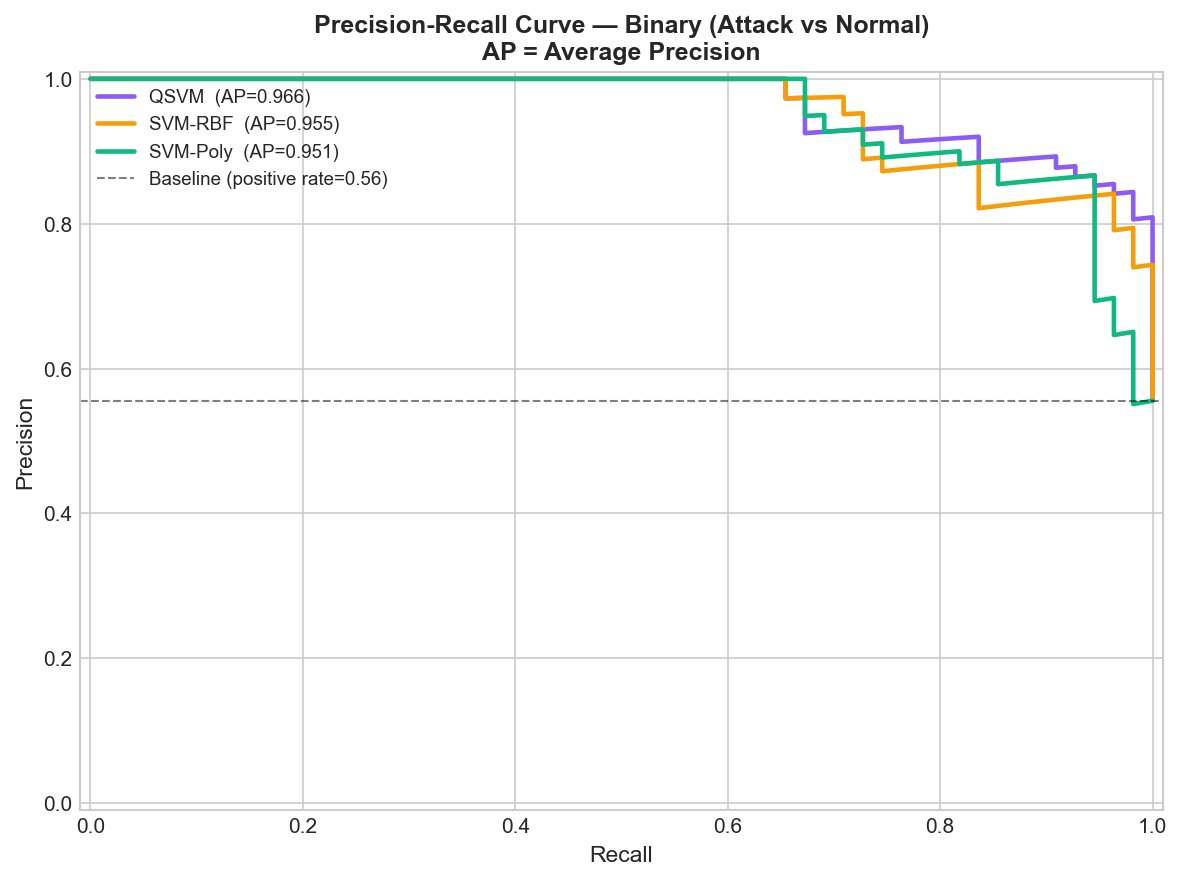


Average Precision (AUC-PR):
  QSVM         | AP=0.9656
  SVM-RBF      | AP=0.9552
  SVM-Poly     | AP=0.9508


In [18]:
pr_auc_vals, pr_data = {}, {}
fig, ax = plt.subplots(figsize=(8, 6))

for name in MODEL_NAMES:
    prec, rec, _ = precision_recall_curve(y_test, prob[name])
    ap           = average_precision_score(y_test, prob[name])
    pr_auc_vals[name] = ap
    pr_data[name]     = {'precision': prec.tolist(), 'recall': rec.tolist(), 'ap': ap}
    ax.plot(rec, prec, color=MODEL_COLORS[name], lw=2.2, label=f'{name}  (AP={ap:.3f})')

baseline = float(y_test.mean())
ax.axhline(baseline, color='black', linestyle='--', lw=1, alpha=0.5,
           label=f'Baseline (positive rate={baseline:.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.01)
ax.set_title('Precision-Recall Curve — Binary (Attack vs Normal)\nAP = Average Precision',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'c5_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Luu: reports/c5_pr_curves.png")
display(Image(filename=REPORTS_DIR / 'c5_pr_curves.png'))
print("\nAverage Precision (AUC-PR):")
for name in MODEL_NAMES: print(f"  {name:12s} | AP={pr_auc_vals[name]:.4f}")


### 6.2 Per-Class PR-AUC Heatmap (One-vs-Rest)

Để đi sâu vào cấu trúc hình học của từng không gian ra quyết định, chúng ta áp dụng chiến lược **One-vs-Rest (OVR)**. Tại đây, mỗi nhóm tấn công được luân phiên đặt làm lớp dương (Positive class = 1), trong khi toàn bộ các mẫu còn lại gom thành lớp âm (Negative = 0).

**Mục tiêu phân tích:** Bản đồ nhiệt (Heatmap) này hoạt động như một "máy quét X-Quang", cho phép chúng ta nhìn xuyên qua lớp vỏ bọc hoàn hảo của chỉ số weighted F1-score tổng thể để trả lời trực tiếp câu hỏi: *Trong hai không gian đặc trưng (Lượng tử vs Cổ điển), mô hình nào thực sự "nhìn thấy" và tách biệt được các lớp hiếm U2R/R2L tốt hơn?*

> **Chú ý:** Các ô được đóng khung vuông màu đỏ đánh dấu khu vực kiểm định trọng điểm (Rare Classes).

Luu: reports/c5_perclass_prauc_heatmap.png


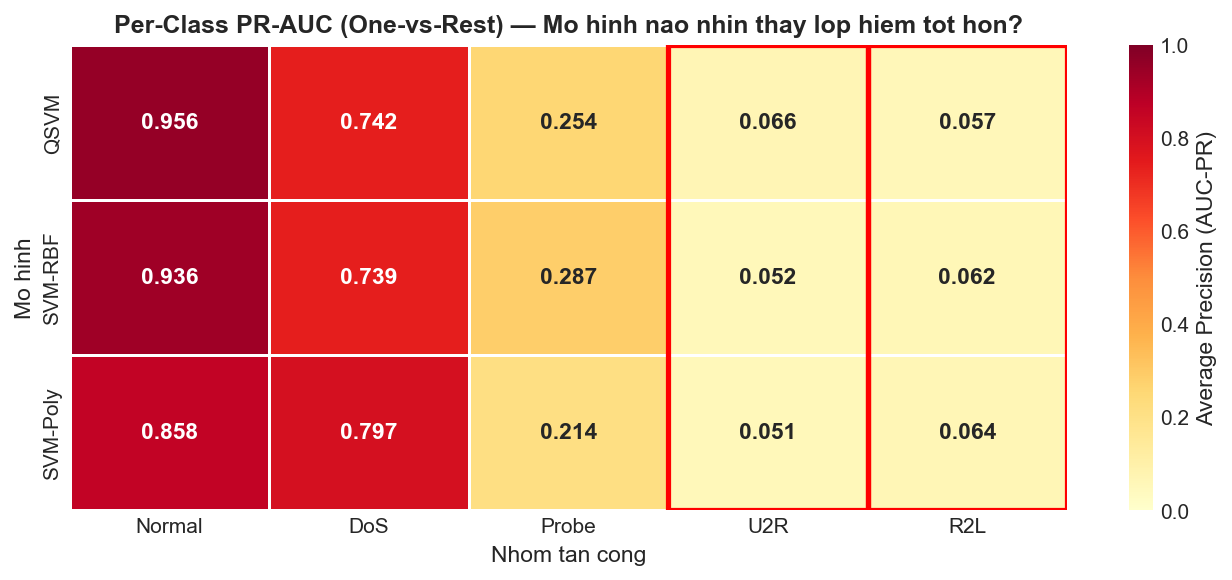


Per-Class AP (AUC-PR):
          Normal    DoS  Probe    U2R    R2L
Model                                       
QSVM       0.956  0.742  0.254  0.066  0.057
SVM-RBF    0.936  0.739  0.287  0.052  0.062
SVM-Poly   0.858  0.797  0.214  0.051  0.064


In [19]:
perclass_ap = {name: {} for name in MODEL_NAMES}
for grp in GROUP_ORDER:
    y_ovr = (group_test == grp).astype(int)
    for name in MODEL_NAMES:
        if y_ovr.sum() == 0:
            perclass_ap[name][grp] = float('nan')
        else:
            score = (1 - prob[name]) if grp == 'Normal' else prob[name]
            perclass_ap[name][grp] = average_precision_score(y_ovr, score)

df_ap = pd.DataFrame(perclass_ap, index=GROUP_ORDER).T
df_ap.index.name = 'Model'

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(df_ap.astype(float), annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Average Precision (AUC-PR)'},
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Per-Class PR-AUC (One-vs-Rest) — Mo hinh nao nhin thay lop hiem tot hon?',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Nhom tan cong'); ax.set_ylabel('Mo hinh')

for j, grp in enumerate(GROUP_ORDER):
    if grp in RARE_GROUPS:
        ax.add_patch(plt.Rectangle((j, 0), 1, len(MODEL_NAMES),
                                   fill=False, edgecolor='red', lw=2.5))

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'c5_perclass_prauc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Luu: reports/c5_perclass_prauc_heatmap.png")
display(Image(filename=REPORTS_DIR / 'c5_perclass_prauc_heatmap.png'))
print("\nPer-Class AP (AUC-PR):")
print(df_ap.round(3).to_string())

## 7: Phân Tích Mẫu Lỗi (Error Analysis) & Ma Trận Nhầm Lẫn

### 7.1 Confusion Matrix — So Sánh Đa Mô Hình

Ma trận nhầm lẫn (Confusion Matrix) cung cấp một cái nhìn trực diện vào **chi tiết các mẫu dự đoán sai (error patterns)**, phơi bày những điểm mù mà các chỉ số đo lường tổng hợp (như Accuracy hay F1-score) thường che khuất.

Trong bối cảnh hệ thống Phát hiện Xâm nhập (IDS), chúng ta cần đặt trọng tâm đánh giá vào 2 loại sai số trí mạng:
* **False Negatives (FN - Âm tính giả):** Mạng đang bị tấn công nhưng hệ thống lại báo an toàn (Normal). Đây là rủi ro **NGUY HIỂM NHẤT**, có thể dẫn đến việc hệ thống bị xâm chiếm hoàn toàn.
* **False Positives (FP - Dương tính giả):** Lưu lượng mạng bình thường (Normal) nhưng lại bị chặn và cảnh báo là tấn công. Tỷ lệ này cao sẽ làm tăng lượng cảnh báo rác (False Alarms), gây ra hiện tượng căng thẳng cảnh báo (alert fatigue) cho các chuyên gia vận hành.

> **Hướng dẫn đọc Ma trận:** > Các giá trị phần trăm (`%`) bên trong mỗi ô đã được chuẩn hóa theo hàng ngang (True class). Số nhỏ nằm trong ngoặc `(n=...)` biểu diễn số lượng đếm tuyệt đối của mẫu dữ liệu rơi vào kịch bản đó.

Luu: reports/c5_confusion_matrices.png


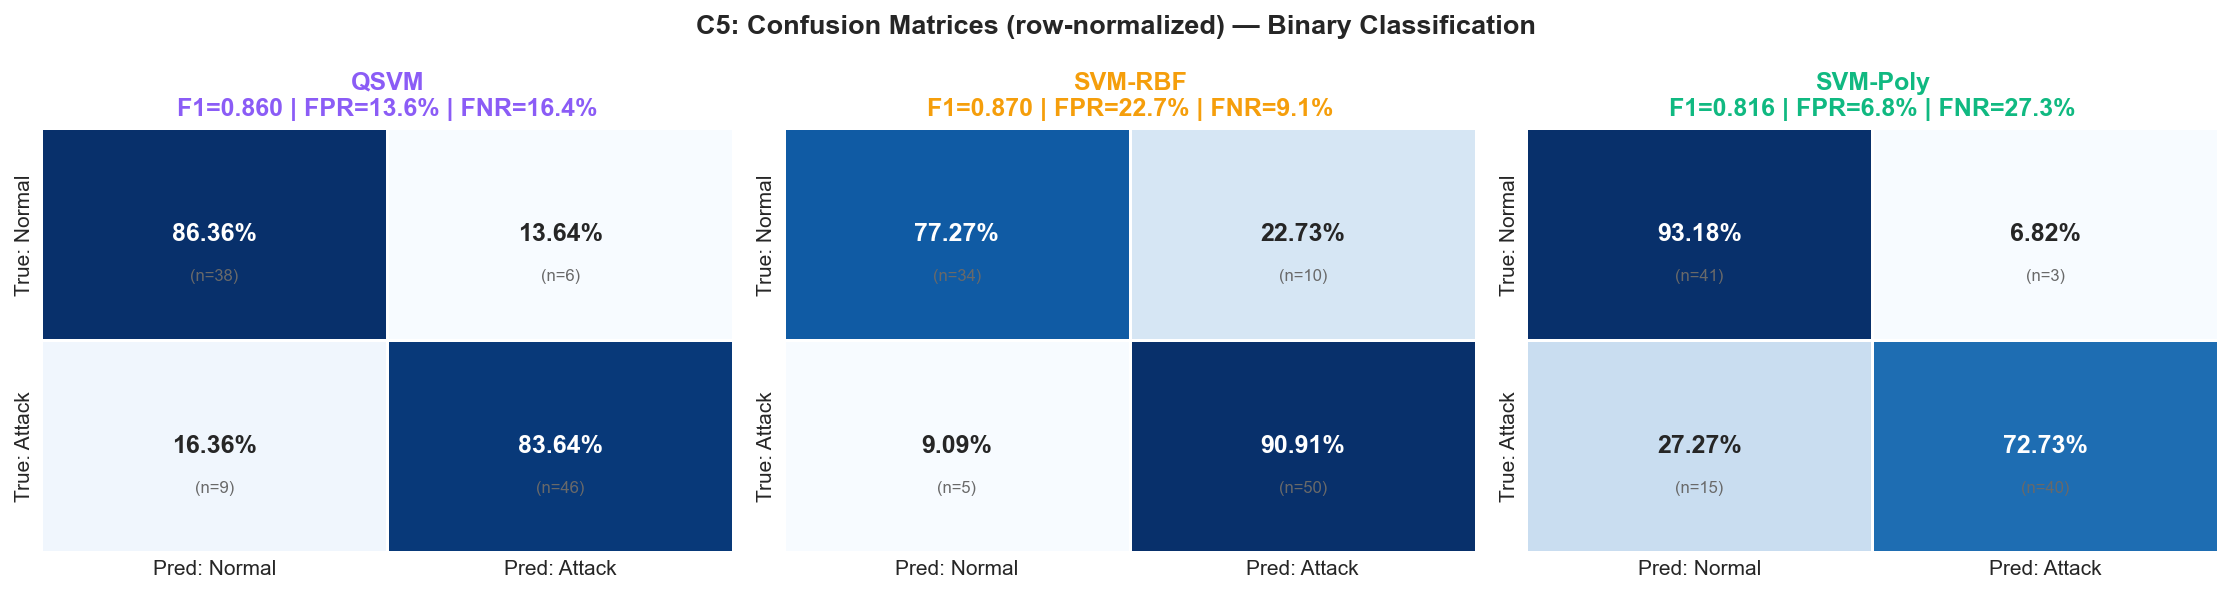

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cm_data = {}
for ax, name in zip(axes, MODEL_NAMES):
    cm = confusion_matrix(y_test, y_pred[name])
    cm_data[name] = cm.tolist()
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                ax=ax, linewidths=0.5, cbar=False,
                xticklabels=['Pred: Normal', 'Pred: Attack'],
                yticklabels=['True: Normal', 'True: Attack'],
                annot_kws={'size': 12, 'weight': 'bold'})
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.72, f'(n={cm[i,j]})',
                    ha='center', fontsize=8, color='dimgrey')

    f1_v  = f1_score(y_test, y_pred[name])
    fpr_v = cm[0,1] / (cm[0,0] + cm[0,1]) if (cm[0,0]+cm[0,1]) > 0 else 0
    fnr_v = cm[1,0] / (cm[1,0] + cm[1,1]) if (cm[1,0]+cm[1,1]) > 0 else 0
    ax.set_title(f'{name}\nF1={f1_v:.3f} | FPR={fpr_v:.1%} | FNR={fnr_v:.1%}',
                 color=MODEL_COLORS[name], fontweight='bold')

plt.suptitle('C5: Confusion Matrices (row-normalized) — Binary Classification',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'c5_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Luu: reports/c5_confusion_matrices.png")
display(Image(filename=REPORTS_DIR / 'c5_confusion_matrices.png'))

### 7.2 Phân Tích Tính Bổ Trợ (Complementarity) — Vùng Ưu Thế Lượng Tử

**Kiểm định Giả thuyết H3:** Liệu có tồn tại những mẫu tấn công hiếm (U2R, R2L) mà không gian Hilbert của mô hình lượng tử (QSVM) có thể phân loại chính xác, trong khi không gian vô hạn chiều của hạt nhân cổ điển (SVM-RBF) lại hoàn toàn bất lực?

Để trả lời câu hỏi này, chúng ta phân rã kết quả dự đoán của 2 mô hình trên tập lớp hiếm thành 4 phân vùng xung đột (Contingency Table):

| Phân Vùng | Ký Hiệu | Diễn Giải Tính Chất Nghiên Cứu |
|:---|:---:|:---|
| **QSVM-wins** | $N_{10}$ | QSVM đúng, RBF sai ➔ Bằng chứng rõ nét nhất của **Ưu thế Lượng tử (Quantum Advantage)** trong việc bắt vi đặc trưng. |
| **RBF-wins** | $N_{01}$ | RBF đúng, QSVM sai ➔ Ưu thế của hạt nhân cổ điển đối với các cụm dữ liệu phân tán. |
| **Both-correct** | $N_{11}$ | Cả hai cùng đúng ➔ Sự đồng thuận về mặt ranh giới (Agreement). |
| **Both-wrong** | $N_{00}$ | Cả hai cùng sai ➔ Điểm mù chung (Hard samples), cần các chiến lược Feature Engineering khác. |

> **Tầm Nhìn Triển Khai (Future Work):** > Nếu phân vùng **QSVM-wins** có chứa dữ liệu ($n \ge 1$), đây sẽ là luận cứ khoa học sắc bén nhất để bảo vệ cho chiến lược xây dựng **Hệ thống IDS Lai (Hybrid Quantum-Classical Ensemble)** trong tương lai, nơi hai mô hình bọc lót các điểm mù cho nhau để tạo ra bức tường phòng thủ hoàn hảo.

  Complementarity — Rare Classes (n=10)
  QSVM-wins   :   1 mau
  RBF-wins    :   2 mau
  Both-correct:   6 mau
  Both-wrong  :   1 mau

QSVM-wins detail (quantum advantage):
 Idx Group  y_true  QSVM_pred  RBF_pred  QSVM_prob  RBF_prob  QSVM_margin  RBF_margin
  86   U2R       1          1         0      0.531     0.019        0.132       -1.16
Luu: reports/c5_complementarity_table.png


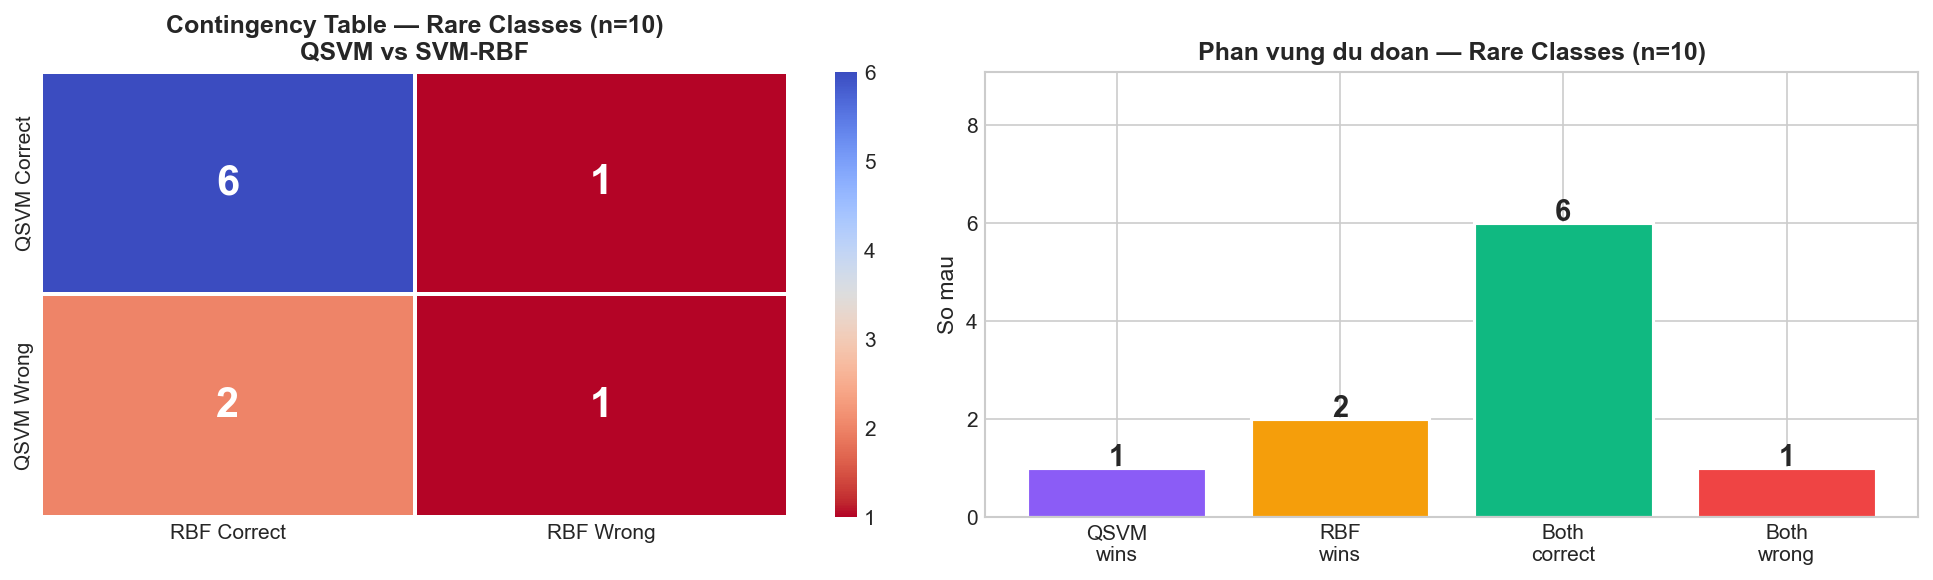

In [25]:
rare_mask    = np.isin(group_test, RARE_GROUPS)
n_rare       = int(rare_mask.sum())

qsvm_correct  = (y_pred['QSVM']    == y_test)
rbf_correct   = (y_pred['SVM-RBF'] == y_test)
poly_correct  = (y_pred['SVM-Poly'] == y_test)

qsvm_wins  = (qsvm_correct  & ~rbf_correct  & rare_mask)
rbf_wins   = (~qsvm_correct &  rbf_correct  & rare_mask)
both_right = (qsvm_correct  &  rbf_correct  & rare_mask)
both_wrong = (~qsvm_correct & ~rbf_correct  & rare_mask)

print("=" * 55)
print(f"  Complementarity — Rare Classes (n={n_rare})")
print("=" * 55)
print(f"  QSVM-wins   : {qsvm_wins.sum():3d} mau")
print(f"  RBF-wins    : {rbf_wins.sum():3d} mau")
print(f"  Both-correct: {both_right.sum():3d} mau")
print(f"  Both-wrong  : {both_wrong.sum():3d} mau")
print("=" * 55)

if qsvm_wins.sum() > 0:
    idx_qwin = np.where(qsvm_wins)[0]
    df_qw = pd.DataFrame({
        'Idx':         idx_qwin,
        'Group':       group_test[idx_qwin],
        'y_true':      y_test[idx_qwin],
        'QSVM_pred':   y_pred['QSVM'][idx_qwin],
        'RBF_pred':    y_pred['SVM-RBF'][idx_qwin],
        'QSVM_prob':   prob['QSVM'][idx_qwin].round(3),
        'RBF_prob':    prob['SVM-RBF'][idx_qwin].round(3),
        'QSVM_margin': df_scores['QSVM'][idx_qwin].round(3),
        'RBF_margin':  df_scores['SVM-RBF'][idx_qwin].round(3),
    })
    print(f"\nQSVM-wins detail (quantum advantage):")
    print(df_qw.to_string(index=False))

# ── Contingency table heatmap + bar chart ─────────────────────────────────────
contingency = np.array([
    [both_right.sum(), qsvm_wins.sum()], 
    [rbf_wins.sum(),   both_wrong.sum()],
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(contingency, annot=True, fmt='d', cmap='coolwarm_r', ax=ax1, cbar=True,
            xticklabels=['RBF Correct', 'RBF Wrong'],
            yticklabels=['QSVM Correct', 'QSVM Wrong'],
            annot_kws={'size': 20, 'weight': 'bold'}, linewidths=1)
ax1.set_title(f'Contingency Table — Rare Classes (n={n_rare})\nQSVM vs SVM-RBF',
              fontweight='bold')

bars_d = {
    'QSVM\nwins': int(qsvm_wins.sum()), 'RBF\nwins': int(rbf_wins.sum()),
    'Both\ncorrect': int(both_right.sum()), 'Both\nwrong': int(both_wrong.sum()),
}
bar_c = ['#8B5CF6', '#F59E0B', '#10B981', '#EF4444']
ax2.bar(bars_d.keys(), bars_d.values(), color=bar_c, edgecolor='white', lw=1.5)
for i, (k, v) in enumerate(bars_d.items()):
    ax2.text(i, v + 0.05, str(v), ha='center', fontsize=14, fontweight='bold')
ax2.set_ylabel('So mau')
ax2.set_title(f'Phan vung du doan — Rare Classes (n={n_rare})', fontweight='bold')
ax2.set_ylim(0, max(bars_d.values()) * 1.35 + 1)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'c5_complementarity_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Luu: reports/c5_complementarity_table.png")
display(Image(filename=REPORTS_DIR / 'c5_complementarity_table.png'))

### 7.3 Kiểm Định Thống Kê — McNemar's Test & Cohen's d

Để đảm bảo các kết luận rút ra không chịu ảnh hưởng bởi yếu tố ngẫu nhiên (đặc biệt khi cỡ mẫu RARE cực kỳ nhỏ), chúng ta áp dụng hệ thống kiểm định thống kê kép:

**1. Kiểm định McNemar (Đánh giá tính khác biệt của Mô hình):**
Kiểm định McNemar [McNemar, 1947] với hiệu chỉnh liên tục (continuity correction) được sử dụng để đánh giá xem sự phân kỳ trong các dự đoán sai của QSVM và SVM-RBF có mang **ý nghĩa thống kê (statistical significance)** hay không.
$$\chi^2 = \frac{(|b - c| - 1)^2}{b + c} \sim \chi^2(df=1)$$
* **$b$**: Số lượng mẫu QSVM-wins (QSVM đúng, RBF sai).
* **$c$**: Số lượng mẫu RBF-wins (RBF đúng, QSVM sai).

**2. Cohen's d (Đánh giá Kích thước Hiệu ứng Biên quyết định):**
Kiểm định p-value đôi khi không phản ánh hết độ lớn của vấn đề. Chỉ số **Cohen's d** được sử dụng để đo lường **kích thước hiệu ứng (effect size)** của sự khác biệt giữa hai phân bố độ tự tin (trị tuyệt đối của decision margin) trên lớp hiếm.
$$d = \frac{\mu_{\text{QSVM}} - \mu_{\text{RBF}}}{\sigma_{\text{pooled}}}$$
> *(Quy ước đánh giá: $|d| \approx 0.2$ là hiệu ứng nhỏ; $0.5$ là trung bình; $\ge 0.8$ là hiệu ứng lớn).*

In [26]:
b = int(qsvm_wins.sum())
c = int(rbf_wins.sum())

print("=" * 55)
print("  McNemar Test — QSVM vs SVM-RBF (Rare Classes)")
print("=" * 55)
print(f"  b (QSVM-wins) = {b}")
print(f"  c (RBF-wins)  = {c}")

if b + c > 0:
    chi2_stat = (abs(b - c) - 1) ** 2 / (b + c)
    p_value   = 1 - chi2_dist.cdf(chi2_stat, df=1)
    print(f"\n  chi2 = {chi2_stat:.4f}")
    print(f"  p-value = {p_value:.4f}")
    sig = "Co y nghia thong ke (p < 0.05)" if p_value < 0.05 else "Khong co y nghia (p >= 0.05)"
    print(f"  Ket luan: {sig}")
else:
    chi2_stat = float('nan')
    p_value   = float('nan')
    print("  [WARN] b + c = 0 — khong du mau bat dong de kiem dinh.")

# ── Cohen's d: phan phoi |margin| tren rare class ────────────────────────────
print("\n" + "=" * 55)
print("  Cohen's d — |Margin| tren Rare Classes: QSVM vs RBF")
print("=" * 55)
qm = np.abs(df_scores['QSVM'][rare_mask])
rm = np.abs(df_scores['SVM-RBF'][rare_mask])

if len(qm) > 1:
    pooled = np.sqrt((qm.std()**2 + rm.std()**2) / 2)
    cohens_d = float((qm.mean() - rm.mean()) / (pooled + 1e-9))
    print(f"  QSVM  |margin|: mean={qm.mean():.3f}, std={qm.std():.3f}")
    print(f"  RBF   |margin|: mean={rm.mean():.3f}, std={rm.std():.3f}")
    print(f"  Cohen's d = {cohens_d:.4f}")
    size_lbl = 'Rat nho' if abs(cohens_d)<0.2 else ('Nho' if abs(cohens_d)<0.5
               else ('Trung binh' if abs(cohens_d)<0.8 else 'Lon'))
    print(f"  Effect size: '{size_lbl}'")
else:
    cohens_d = float('nan')
    print("  [WARN] Khong du mau rare class de tinh Cohen's d.")

stat_results = {
    'mcnemar': {'b': b, 'c': c, 'chi2': float(chi2_stat), 'p_value': float(p_value)},
    'cohens_d_margin_rare': cohens_d,
}
print("\nKet qua kiem dinh thong ke da ghi nhan.")


  McNemar Test — QSVM vs SVM-RBF (Rare Classes)
  b (QSVM-wins) = 1
  c (RBF-wins)  = 2

  chi2 = 0.0000
  p-value = 1.0000
  Ket luan: Khong co y nghia (p >= 0.05)

  Cohen's d — |Margin| tren Rare Classes: QSVM vs RBF
  QSVM  |margin|: mean=0.389, std=0.189
  RBF   |margin|: mean=0.560, std=0.301
  Cohen's d = -0.6805
  Effect size: 'Trung binh'

Ket qua kiem dinh thong ke da ghi nhan.


## Bước 8: Tổng Hợp Kết Quả & Lưu Trữ (Export Results)

Cell này thực hiện nhiệm vụ tập hợp **toàn bộ các chỉ số (metrics) cốt lõi** đã tính toán xuyên suốt quá trình thực nghiệm C5 vào một cấu trúc dữ liệu duy nhất và xuất ra file hệ thống `c5_results.json`.

Việc lưu trữ tập trung dữ liệu này phục vụ 3 mục đích chiến lược:
* **Trích dẫn khoa học:** Cung cấp số liệu thô chính xác để điền vào các bảng biểu so sánh trong luận văn hoặc bài báo quốc tế mà không sai sót.
* **Tính kế thừa:** Các chỉ số hiệu chuẩn (Calibration) và kết quả kiểm định này sẽ được tái sử dụng để làm đối trọng so sánh trong **Đóng góp 6 (C6)**.
* **Tính tái lập (Reproducibility):** Đảm bảo bất kỳ ai cũng có thể kiểm tra và đối chiếu kết quả thực nghiệm một cách độc lập mà không nhất thiết phải chạy lại toàn bộ quy trình mô phỏng lượng tử tốn kém thời gian.

>  **Đường dẫn lưu trữ:** `data/processed_data/c5_results.json`

In [27]:
c5_results = {
    "contribution": "C5",
    "title": "Confidence Calibration va Phan Tich Tan Cong Hiem",
    "config": {
        "config_tag":         CONFIG_TAG,
        "test_size":          int(len(y_test)),
        "train_size":         int(len(y_train)),
        "calibration_method": "Platt Scaling (LogisticRegression C=1e10)",
        "binning_strategy":   "Adaptive Equal-Frequency Binning",
        "n_bins_full":        10,
        "n_bins_rare":        5,
        "rare_classes":       RARE_GROUPS,
        "n_rare_test":        int(rare_mask.sum()),
        "models": {
            "QSVM":    {"type": "QSVC",  "n_support": qsvm.n_support_.tolist()},
            "SVM-RBF": {"type": "SVC",   "kernel": "rbf",  "C": rbf.C,
                        "n_support": rbf.n_support_.tolist()},
            "SVM-Poly":{"type": "SVC",   "kernel": "poly", "degree": poly.degree,
                        "n_support": poly.n_support_.tolist()},
        },
    },
    "platt_params": platt_params,
    "calibration": {
        name: {
            "ece_full": round(ece_results[name]["ece_full"], 5),
            "mce_full": round(ece_results[name]["mce_full"], 5),
            "ece_rare": round(ece_results[name]["ece_rare"], 5),
            "mce_rare": round(ece_results[name]["mce_rare"], 5),
        }
        for name in MODEL_NAMES
    },
    "binary_performance": {
        name: {
            "f1":  round(float(f1_score(y_test, y_pred[name])), 5),
            "acc": round(float(accuracy_score(y_test, y_pred[name])), 5),
        }
        for name in MODEL_NAMES
    },
    "per_group_accuracy": {
        grp: {name: round(float(per_group_acc[grp][name]), 5) for name in MODEL_NAMES}
        for grp in per_group_acc
    },
    "roc_auc":       {name: round(float(roc_auc_vals[name]), 5) for name in MODEL_NAMES},
    "pr_auc_binary": {name: round(float(pr_auc_vals[name]),  5) for name in MODEL_NAMES},
    "pr_auc_per_class": {
        grp: {
            name: round(float(perclass_ap[name][grp]), 5)
                  if not (perclass_ap[name][grp] != perclass_ap[name][grp]) else None
            for name in MODEL_NAMES
        }
        for grp in GROUP_ORDER
    },
    "complementarity_rare": {
        "qsvm_wins":    int(qsvm_wins.sum()),
        "rbf_wins":     int(rbf_wins.sum()),
        "both_correct": int(both_right.sum()),
        "both_wrong":   int(both_wrong.sum()),
    },
    "statistical_tests": {
        "mcnemar_chi2":         None if (stat_results["mcnemar"]["chi2"] !=
                                stat_results["mcnemar"]["chi2"])
                                else round(stat_results["mcnemar"]["chi2"], 5),
        "mcnemar_p_value":      None if (stat_results["mcnemar"]["p_value"] !=
                                stat_results["mcnemar"]["p_value"])
                                else round(stat_results["mcnemar"]["p_value"], 5),
        "cohens_d_margin_rare": None if (stat_results["cohens_d_margin_rare"] !=
                                stat_results["cohens_d_margin_rare"])
                                else round(stat_results["cohens_d_margin_rare"], 5),
    },
    "reports_generated": [
        "reports/c5_class_distribution.png",
        "reports/c5_probability_distributions.png",
        "reports/c5_reliability_diagrams_full.png",
        "reports/c5_reliability_diagrams_rare.png",
        "reports/c5_margin_histograms.png",
        "reports/c5_roc_curves.png",
        "reports/c5_pr_curves.png",
        "reports/c5_perclass_prauc_heatmap.png",
        "reports/c5_confusion_matrices.png",
        "reports/c5_complementarity_table.png",
    ],
}

out_path = DATA_DIR / 'c5_results.json'
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(c5_results, f, ensure_ascii=False, indent=2)

print("=" * 60)
print("  C5 — Tong ket ket qua")
print("=" * 60)
print(f"\n  Calibration ECE (full / rare):")
for name in MODEL_NAMES:
    e = ece_results[name]
    print(f"    {name:12s} | ECE_full={e['ece_full']:.4f} | ECE_rare={e['ece_rare']:.4f}")

print(f"\n  AUC-ROC  / AUC-PR:")
for name in MODEL_NAMES:
    print(f"    {name:12s} | ROC={roc_auc_vals[name]:.4f} | PR={pr_auc_vals[name]:.4f}")

sr = stat_results
print(f"\n  McNemar: chi2={sr['mcnemar']['chi2']:.4f}, p={sr['mcnemar']['p_value']:.4f}")
print(f"  Cohen's d (margin, rare): {sr['cohens_d_margin_rare']:.4f}")
print(f"\n  Ket qua luu tai: {out_path.resolve()}")
print("  Dong gop C5 hoan thanh!")


  C5 — Tong ket ket qua

  Calibration ECE (full / rare):
    QSVM         | ECE_full=0.1065 | ECE_rare=0.4337
    SVM-RBF      | ECE_full=0.1219 | ECE_rare=0.4707
    SVM-Poly     | ECE_full=0.0980 | ECE_rare=0.6191

  AUC-ROC  / AUC-PR:
    QSVM         | ROC=0.9574 | PR=0.9656
    SVM-RBF      | ROC=0.9409 | PR=0.9552
    SVM-Poly     | ROC=0.9256 | PR=0.9508

  McNemar: chi2=0.0000, p=1.0000
  Cohen's d (margin, rare): -0.6805

  Ket qua luu tai: D:\QSVM_NSLKDD\data\processed_data\c5_results.json
  Dong gop C5 hoan thanh!
